In [ ]:
def save_slices_for_specific_case(model, test_loader, device, target_filename):
    """
    Process a specific test sample by filename and save all slices as individual images
    
    Args:
        model: trained model
        test_loader: DataLoader for test data
        device: torch device
        target_filename: str - specific filename to process (e.g., "BraTS2024_SSA_00123_0000.npz")
    """
    
    print(f"Looking for specific case: {target_filename}")
    print("="*80)
    
    for batch_idx, (images, masks, filenames) in enumerate(test_loader):
        # Process each sample in batch
        for i in range(images.shape[0]):
            filename = filenames[i]
            
            # Check if this is the target file
            if filename == target_filename:
                image = images[i]
                true_mask = masks[i].numpy()
                
                print(f"✅ Found target case: {filename}")
                print(f"   Image shape: {image.shape}")
                print(f"   Mask shape: {true_mask.shape}")
                
                # Get prediction
                pred_mask, _ = predict_single_volume(model, image, device)
                
                # Save all slices as individual images
                case_dir = save_all_slices_as_images(
                    image.numpy(), 
                    true_mask, 
                    pred_mask, 
                    filename
                )
                
                print(f"✅ Successfully processed {filename}")
                return case_dir
    
    print(f"❌ File '{target_filename}' not found in test dataset")
    print("Available files:")
    for batch_idx, (images, masks, filenames) in enumerate(test_loader):
        for filename in filenames:
            print(f"  - {filename}")
        if batch_idx >= 10:  # Show only first 10 batches
            print("  ... (more files)")
            break
    return None


def list_available_test_files(test_loader, max_display=20):
    """
    List available files in the test dataset
    
    Args:
        test_loader: DataLoader for test data
        max_display: maximum number of files to display
    """
    
    print("Available test files:")
    print("="*50)
    
    count = 0
    for batch_idx, (images, masks, filenames) in enumerate(test_loader):
        for filename in filenames:
            print(f"{count+1:3d}. {filename}")
            count += 1
            if count >= max_display:
                print(f"... and {len(test_dataset) - count} more files")
                return
    
    print(f"\nTotal: {count} files")


print("Additional functions defined!")
print("\nTo list available files:")
print("list_available_test_files(test_loader)")
print("\nTo process a specific file:")
print("case_dir = save_slices_for_specific_case(model, test_loader, DEVICE, 'filename.npz')")

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np

def save_all_slices_as_images(image, true_mask, pred_mask, filename, base_output_dir="slice_images"):
    """
    Save all slices of image, true mask, predicted mask, and error map as individual PNG files
    organized in separate folders.
    
    Args:
        image: 4D numpy array (channels, H, W, D) - original image
        true_mask: 3D numpy array (H, W, D) - ground truth mask
        pred_mask: 3D numpy array (H, W, D) - predicted mask
        filename: str - original filename for identification
        base_output_dir: str - base directory for saving images
    """
    
    # Create base directory
    os.makedirs(base_output_dir, exist_ok=True)
    
    # Remove .npz extension from filename for folder naming
    case_name = filename.replace('.npz', '')
    
    # Create subdirectories for this case
    case_dir = os.path.join(base_output_dir, case_name)
    original_dir = os.path.join(case_dir, "original")
    true_mask_dir = os.path.join(case_dir, "true_mask")
    pred_mask_dir = os.path.join(case_dir, "predicted_mask")
    error_dir = os.path.join(case_dir, "errors")
    
    for dir_path in [original_dir, true_mask_dir, pred_mask_dir, error_dir]:
        os.makedirs(dir_path, exist_ok=True)
    
    # Get dimensions
    channels, height, width, depth = image.shape
    
    print(f"Saving {depth} slices for case: {case_name}")
    
    # Calculate error map once
    error_map = (true_mask != pred_mask).astype(int)
    
    # Save each slice
    for slice_idx in range(depth):
        slice_num_str = f"{slice_idx+1:04d}"  # Zero-padded slice number
        
        # 1. Save original image (first channel)
        plt.figure(figsize=(8, 8))
        plt.imshow(image[0, :, :, slice_idx], cmap='viridis')
        plt.axis('off')
        plt.tight_layout()
        plt.savefig(os.path.join(original_dir, f"original_{slice_num_str}.png"), 
                   dpi=150, bbox_inches='tight', pad_inches=0)
        plt.close()
        
        # 2. Save true mask
        plt.figure(figsize=(8, 8))
        plt.imshow(true_mask[:, :, slice_idx], cmap='viridis', vmin=0, vmax=4)
        plt.axis('off')
        plt.tight_layout()
        plt.savefig(os.path.join(true_mask_dir, f"true_mask_{slice_num_str}.png"), 
                   dpi=150, bbox_inches='tight', pad_inches=0)
        plt.close()
        
        # 3. Save predicted mask
        plt.figure(figsize=(8, 8))
        plt.imshow(pred_mask[:, :, slice_idx], cmap='viridis', vmin=0, vmax=4)
        plt.axis('off')
        plt.tight_layout()
        plt.savefig(os.path.join(pred_mask_dir, f"predicted_mask_{slice_num_str}.png"), 
                   dpi=150, bbox_inches='tight', pad_inches=0)
        plt.close()
        
        # 4. Save error map
        plt.figure(figsize=(8, 8))
        plt.imshow(error_map[:, :, slice_idx], cmap='viridis', vmin=0, vmax=1)
        plt.axis('off')
        plt.tight_layout()
        plt.savefig(os.path.join(error_dir, f"errors_{slice_num_str}.png"), 
                   dpi=150, bbox_inches='tight', pad_inches=0)
        plt.close()
    
    print(f"✓ Saved all {depth} slices for {case_name}")
    return case_dir


def save_slices_for_samples(model, test_loader, device, max_samples=3):
    """
    Process test samples and save all slices as individual images
    
    Args:
        model: trained model
        test_loader: DataLoader for test data
        device: torch device
        max_samples: maximum number of samples to process
    """
    
    print(f"Processing {max_samples} samples for slice extraction...")
    print("="*80)
    
    sample_count = 0
    case_dirs = []
    
    for batch_idx, (images, masks, filenames) in enumerate(test_loader):
        if sample_count >= max_samples:
            break
            
        # Process each sample in batch
        for i in range(images.shape[0]):
            image = images[i]
            true_mask = masks[i].numpy()
            filename = filenames[i]
            
            print(f"\n📁 Processing sample {sample_count + 1}/{max_samples}: {filename}")
            
            # Get prediction
            pred_mask, _ = predict_single_volume(model, image, device)
            
            # Save all slices as individual images
            case_dir = save_all_slices_as_images(
                image.numpy(), 
                true_mask, 
                pred_mask, 
                filename
            )
            
            case_dirs.append(case_dir)
            sample_count += 1
            
            # Clear memory
            torch.cuda.empty_cache()
            gc.collect()
            
            if sample_count >= max_samples:
                break
    
    print("\n" + "="*80)
    print("📸 SLICE EXTRACTION COMPLETE!")
    print("="*80)
    
    return case_dirs


print("Functions defined! Ready to use slice extraction.")
print("To use, run: case_dirs = save_slices_for_samples(model, test_loader, DEVICE, max_samples=3)")

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np

def save_all_slices_as_images(image, true_mask, pred_mask, filename, base_output_dir="slice_images"):
    """
    Save all slices of image, true mask, predicted mask, and error map as individual PNG files
    organized in separate folders for easy video creation with ffmpeg.
    
    Args:
        image: 4D numpy array (channels, H, W, D) - original image
        true_mask: 3D numpy array (H, W, D) - ground truth mask
        pred_mask: 3D numpy array (H, W, D) - predicted mask
        filename: str - original filename for identification
        base_output_dir: str - base directory for saving images
    """
    
    # Create base directory
    os.makedirs(base_output_dir, exist_ok=True)
    
    # Remove .npz extension from filename for folder naming
    case_name = filename.replace('.npz', '')
    
    # Create subdirectories for this case
    case_dir = os.path.join(base_output_dir, case_name)
    original_dir = os.path.join(case_dir, "original")
    true_mask_dir = os.path.join(case_dir, "true_mask")
    pred_mask_dir = os.path.join(case_dir, "predicted_mask")
    error_dir = os.path.join(case_dir, "errors")
    
    for dir_path in [original_dir, true_mask_dir, pred_mask_dir, error_dir]:
        os.makedirs(dir_path, exist_ok=True)
    
    # Get dimensions
    channels, height, width, depth = image.shape
    
    print(f"Saving {depth} slices for case: {case_name}")
    
    # Calculate error map once
    error_map = (true_mask != pred_mask).astype(int)
    
    # Save each slice
    for slice_idx in range(depth):
        slice_num_str = f"{slice_idx+1:04d}"  # Zero-padded slice number
        
        # 1. Save original image (first channel - usually FLAIR)
        fig, ax = plt.subplots(1, 1, figsize=(8, 8))
        ax.imshow(image[0, :, :, slice_idx], cmap='gray')
        ax.axis('off')
        ax.set_title(f'Original - Slice {slice_idx+1}')
        plt.tight_layout()
        plt.savefig(os.path.join(original_dir, f"original_{slice_num_str}.png"), 
                   dpi=150, bbox_inches='tight', facecolor='white')
        plt.close()
        
        # 2. Save true mask
        fig, ax = plt.subplots(1, 1, figsize=(8, 8))
        im = ax.imshow(true_mask[:, :, slice_idx], cmap='viridis', vmin=0, vmax=4)
        ax.axis('off')
        ax.set_title(f'True Mask - Slice {slice_idx+1}')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        plt.tight_layout()
        plt.savefig(os.path.join(true_mask_dir, f"true_mask_{slice_num_str}.png"), 
                   dpi=150, bbox_inches='tight', facecolor='white')
        plt.close()
        
        # 3. Save predicted mask
        fig, ax = plt.subplots(1, 1, figsize=(8, 8))
        im = ax.imshow(pred_mask[:, :, slice_idx], cmap='viridis', vmin=0, vmax=4)
        ax.axis('off')
        ax.set_title(f'Predicted Mask - Slice {slice_idx+1}')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        plt.tight_layout()
        plt.savefig(os.path.join(pred_mask_dir, f"predicted_mask_{slice_num_str}.png"), 
                   dpi=150, bbox_inches='tight', facecolor='white')
        plt.close()
        
        # 4. Save error map
        fig, ax = plt.subplots(1, 1, figsize=(8, 8))
        im = ax.imshow(error_map[:, :, slice_idx], cmap='Reds', vmin=0, vmax=1)
        ax.axis('off')
        ax.set_title(f'Errors - Slice {slice_idx+1}')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        plt.tight_layout()
        plt.savefig(os.path.join(error_dir, f"errors_{slice_num_str}.png"), 
                   dpi=150, bbox_inches='tight', facecolor='white')
        plt.close()
    
    print(f"✓ Saved all {depth} slices for {case_name}")
    print(f"  - Original images: {original_dir}")
    print(f"  - True masks: {true_mask_dir}")
    print(f"  - Predicted masks: {pred_mask_dir}")
    print(f"  - Error maps: {error_dir}")
    
    return case_dir


def create_slice_videos_for_case(case_dir, framerate=10):
    """
    Create MP4 videos from saved slice images using ffmpeg
    
    Args:
        case_dir: str - path to case directory containing slice folders
        framerate: int - frames per second for videos
    """
    case_name = os.path.basename(case_dir)
    
    # Define the subdirectories and their corresponding video names
    slice_types = {
        "original": "original_video.mp4",
        "true_mask": "true_mask_video.mp4", 
        "predicted_mask": "predicted_mask_video.mp4",
        "errors": "errors_video.mp4"
    }
    
    print(f"\nCreating videos for case: {case_name}")
    
    for folder_name, video_name in slice_types.items():
        folder_path = os.path.join(case_dir, folder_name)
        
        if not os.path.exists(folder_path):
            print(f"  ⚠️  Folder not found: {folder_path}")
            continue
            
        # Count PNG files in folder
        png_files = [f for f in os.listdir(folder_path) if f.endswith('.png')]
        if len(png_files) == 0:
            print(f"  ⚠️  No PNG files found in: {folder_path}")
            continue
            
        # Create video output path
        video_path = os.path.join(case_dir, video_name)
        
        # Construct ffmpeg command
        # Use the appropriate pattern based on saved filenames
        if folder_name == "original":
            pattern = os.path.join(folder_path, "original_%04d.png")
        elif folder_name == "true_mask":
            pattern = os.path.join(folder_path, "true_mask_%04d.png")
        elif folder_name == "predicted_mask":
            pattern = os.path.join(folder_path, "predicted_mask_%04d.png")
        else:  # errors
            pattern = os.path.join(folder_path, "errors_%04d.png")
        
        cmd = f'ffmpeg -y -framerate {framerate} -i "{pattern}" -c:v libx264 -pix_fmt yuv420p "{video_path}"'
        
        print(f"  📹 Creating {video_name}...")
        result = os.system(cmd + " > /dev/null 2>&1")  # Suppress ffmpeg output
        
        if result == 0:
            print(f"  ✓ Created: {video_name}")
        else:
            print(f"  ❌ Failed to create: {video_name}")
    
    print(f"\n✓ Video creation complete for {case_name}")


def save_slices_and_create_videos_for_samples(model, test_loader, device, max_samples=3, framerate=10):
    """
    Process test samples, save all slices as individual images, and create videos
    
    Args:
        model: trained model
        test_loader: DataLoader for test data
        device: torch device
        max_samples: maximum number of samples to process
        framerate: frames per second for videos
    """
    
    print(f"Processing {max_samples} samples for slice extraction and video creation...")
    print("="*80)
    
    sample_count = 0
    
    for batch_idx, (images, masks, filenames) in enumerate(test_loader):
        if sample_count >= max_samples:
            break
            
        # Process each sample in batch
        for i in range(images.shape[0]):
            image = images[i]
            true_mask = masks[i].numpy()
            filename = filenames[i]
            
            print(f"\n📁 Processing sample {sample_count + 1}/{max_samples}: {filename}")
            print(f"   Image shape: {image.shape}")
            print(f"   Mask shape: {true_mask.shape}")
            
            # Get prediction
            pred_mask, _ = predict_single_volume(model, image, device)
            
            # Save all slices as individual images
            case_dir = save_all_slices_as_images(
                image.numpy(), 
                true_mask, 
                pred_mask, 
                filename
            )
            
            # Create videos from the saved slices
            create_slice_videos_for_case(case_dir, framerate=framerate)
            
            sample_count += 1
            
            # Clear memory
            torch.cuda.empty_cache()
            gc.collect()
            
            if sample_count >= max_samples:
                break
    
    print("\n" + "="*80)
    print("🎬 SLICE EXTRACTION AND VIDEO CREATION COMPLETE!")
    print("="*80)
    print("\nDirectory structure created:")
    print("slice_images/")
    print("├── case_001/")
    print("│   ├── original/          # Original image slices")
    print("│   ├── true_mask/         # Ground truth mask slices")
    print("│   ├── predicted_mask/    # Model prediction slices")
    print("│   ├── errors/           # Error/difference slices")
    print("│   ├── original_video.mp4")
    print("│   ├── true_mask_video.mp4")
    print("│   ├── predicted_mask_video.mp4")
    print("│   └── errors_video.mp4")
    print("└── case_002/")
    print("    └── ... (same structure)")
    print("\n💡 You can now use these videos for presentations or further analysis!")

# Example usage - uncomment to run
print("Functions defined! Ready to use slice extraction and video creation.")
print("\nTo use these functions, run:")
print("save_slices_and_create_videos_for_samples(model, test_loader, DEVICE, max_samples=3)")

Functions defined! Ready to use slice extraction and video creation.

To use these functions, run:
save_slices_and_create_videos_for_samples(model, test_loader, DEVICE, max_samples=3)


# BraTS 2024 Model Validation & Prediction Analysis
Load trained model checkpoint and perform validation on test set with visualizations and metrics.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchmetrics import MeanMetric
from torchmetrics.classification import MulticlassAccuracy
from tqdm import tqdm
import gc
from dataclasses import dataclass
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

In [4]:
# Configuration
@dataclass(frozen=True)
class ValidationConfig:
    # Paths
    CHECKPOINT_PATH: str = "/home/dberl/THESIS/BRAIN_TUMOR_PROJECT/brats2024/ckpt_epoch_60.tar"  # Updated to use 60-epoch model
    TEST_DATA_DIR: str = "/home/dberl/THESIS/BRAIN_TUMOR_PROJECT/brats2024/BraTS2024_Preprocessed/data_test"  # Update this path to your actual test data directory
    
    # Model params
    NUM_CLASSES: int = 5
    BATCH_SIZE: int = 1  # Use batch=1 for detailed analysis
    
    # Visualization
    SLICE_INDICES: list = None  # Will use middle slices
    SAVE_VISUALIZATIONS: bool = True

In [5]:
# Copy model architecture from training notebook
def double_conv(in_channels, out_channels):
    return nn.Sequential(
        nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1),
        nn.BatchNorm3d(out_channels),
        nn.ReLU(inplace=True),
        nn.Conv3d(out_channels, out_channels, kernel_size=3, padding=1),
        nn.BatchNorm3d(out_channels),
        nn.ReLU(inplace=True)
    )

class UNet3D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        # Contraction path
        self.conv1 = double_conv(in_channels=in_channels, out_channels=16)
        self.pool1 = nn.MaxPool3d(kernel_size=2)

        self.conv2 = double_conv(in_channels=16, out_channels=32)
        self.pool2 = nn.MaxPool3d(kernel_size=2)

        self.conv3 = double_conv(in_channels=32, out_channels=64)
        self.pool3 = nn.MaxPool3d(kernel_size=2)

        self.conv4 = double_conv(in_channels=64, out_channels=128)
        self.pool4 = nn.MaxPool3d(kernel_size=2)

        self.conv5 = double_conv(in_channels=128, out_channels=256)

        # Expansive path
        self.upconv6 = nn.ConvTranspose3d(in_channels=256, out_channels=128, kernel_size=2, stride=2)
        self.conv6 = double_conv(in_channels=256, out_channels=128)

        self.upconv7 = nn.ConvTranspose3d(in_channels=128, out_channels=64, kernel_size=2, stride=2)
        self.conv7 = double_conv(in_channels=128, out_channels=64)

        self.upconv8 = nn.ConvTranspose3d(in_channels=64, out_channels=32, kernel_size=2, stride=2)
        self.conv8 = double_conv(in_channels=64, out_channels=32)

        self.upconv9 = nn.ConvTranspose3d(in_channels=32, out_channels=16, kernel_size=2, stride=2)
        self.conv9 = double_conv(in_channels=32, out_channels=16)

        self.out_conv = nn.Conv3d(in_channels=16, out_channels=out_channels, kernel_size=1)

    def forward(self, x):
        # Contracting path
        c1 = self.conv1(x)
        p1 = self.pool1(c1)

        c2 = self.conv2(p1)
        p2 = self.pool2(c2)

        c3 = self.conv3(p2)
        p3 = self.pool3(c3)

        c4 = self.conv4(p3)
        p4 = self.pool4(c4)

        c5 = self.conv5(p4)

        # Expansive path with interpolation to match sizes
        u6 = self.upconv6(c5)
        u6 = F.interpolate(u6, size=c4.shape[2:], mode='trilinear', align_corners=False)
        u6 = torch.cat([u6, c4], dim=1)
        c6 = self.conv6(u6)

        u7 = self.upconv7(c6)
        u7 = F.interpolate(u7, size=c3.shape[2:], mode='trilinear', align_corners=False)
        u7 = torch.cat([u7, c3], dim=1)
        c7 = self.conv7(u7)

        u8 = self.upconv8(c7)
        u8 = F.interpolate(u8, size=c2.shape[2:], mode='trilinear', align_corners=False)
        u8 = torch.cat([u8, c2], dim=1)
        c8 = self.conv8(u8)

        u9 = self.upconv9(c8)
        u9 = F.interpolate(u9, size=c1.shape[2:], mode='trilinear', align_corners=False)
        u9 = torch.cat([u9, c1], dim=1)
        c9 = self.conv9(u9)

        outputs = self.out_conv(c9)

        return outputs

In [6]:
# Copy dataset class from training notebook
class BraTSDataset(Dataset):
    def __init__(self, data_dir):
        super().__init__()
        self.data_dir = data_dir
        self.file_list = sorted([f for f in os.listdir(data_dir) if f.endswith('.npz')])

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, index):
        file_path = os.path.join(self.data_dir, self.file_list[index])
        data = np.load(file_path)
        image = data['image']
        mask = data['mask']

        image = torch.from_numpy(image).permute(3, 0, 1, 2).float()
        mask = torch.from_numpy(mask).long()
        
        # Return filename for tracking
        return image, mask, self.file_list[index]

In [11]:
def get_device():
    """Get available device"""
    if torch.cuda.is_available():
        device = torch.device('cuda')
        print(f"Using GPU: {torch.cuda.get_device_name()}")
        print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f}GB")
    else:
        device = torch.device('cpu')
        print("Using CPU (this will be slower)")
    return device

DEVICE = get_device()

Using CPU (this will be slower)


In [12]:
def load_model_from_checkpoint(checkpoint_path, device):
    """Load trained model from checkpoint"""
    print(f"Loading model from: {checkpoint_path}")
    
    # Check if checkpoint exists
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")
    
    # Load checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    # Create model
    model = UNet3D(in_channels=3, out_channels=ValidationConfig.NUM_CLASSES)
    model.load_state_dict(checkpoint['model'])
    model.to(device)
    model.eval()
    
    print(f"Model loaded successfully from epoch {checkpoint['epoch']}")
    print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
    
    return model

# Load model
model = load_model_from_checkpoint(ValidationConfig.CHECKPOINT_PATH, DEVICE)

Loading model from: /home/dberl/THESIS/BRAIN_TUMOR_PROJECT/brats2024/ckpt_epoch_60.tar
Model loaded successfully from epoch 60
Model parameters: 5,648,789


In [13]:
# Create test dataset and loader
test_dataset = BraTSDataset(ValidationConfig.TEST_DATA_DIR)
test_loader = DataLoader(
    test_dataset, 
    batch_size=ValidationConfig.BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print(f"Test dataset size: {len(test_dataset)} samples")
print(f"Test loader batches: {len(test_loader)}")

Test dataset size: 110 samples
Test loader batches: 110


In [ ]:
def save_all_slices_4pane_visualization(image, true_mask, pred_mask, filename, base_output_dir="4pane_slices"):
    """
    Save all slices as 4-pane side-by-side visualizations (Original, True Mask, Predicted Mask, Errors)
    Creates one image per slice showing all 4 panes horizontally arranged.
    
    Args:
        image: 4D numpy array (channels, H, W, D) - original image
        true_mask: 3D numpy array (H, W, D) - ground truth mask
        pred_mask: 3D numpy array (H, W, D) - predicted mask
        filename: str - original filename for identification
        base_output_dir: str - base directory for saving images
    """
    
    # Create base directory
    os.makedirs(base_output_dir, exist_ok=True)
    
    # Remove .npz extension from filename for folder naming
    case_name = filename.replace('.npz', '')
    
    # Create subdirectory for this case
    case_dir = os.path.join(base_output_dir, case_name)
    os.makedirs(case_dir, exist_ok=True)
    
    # Get dimensions
    channels, height, width, depth = image.shape
    
    print(f"Creating 4-pane visualizations for {depth} slices of case: {case_name}")
    
    # Calculate error map once
    error_map = (true_mask != pred_mask).astype(int)
    
    # Save each slice as 4-pane visualization
    for slice_idx in range(depth):
        slice_num_str = f"{slice_idx+1:04d}"  # Zero-padded slice number
        
        # Create 4-pane figure (1 row, 4 columns)
        fig, axes = plt.subplots(1, 4, figsize=(20, 5))
        fig.suptitle(f'Slice {slice_idx+1}/{depth} - {case_name}', fontsize=16, fontweight='bold')
        
        # 1. Original image (first channel)
        axes[0].imshow(image[0, :, :, slice_idx], cmap='gray')
        axes[0].set_title(f'Original Image\nSlice {slice_idx+1}', fontsize=12)
        axes[0].axis('off')
        
        # 2. True mask
        im1 = axes[1].imshow(true_mask[:, :, slice_idx], cmap='viridis', vmin=0, vmax=4)
        axes[1].set_title(f'Ground Truth Mask\nSlice {slice_idx+1}', fontsize=12)
        axes[1].axis('off')
        
        # 3. Predicted mask
        im2 = axes[2].imshow(pred_mask[:, :, slice_idx], cmap='viridis', vmin=0, vmax=4)
        axes[2].set_title(f'Predicted Mask\nSlice {slice_idx+1}', fontsize=12)
        axes[2].axis('off')
        
        # 4. Error map
        im3 = axes[3].imshow(error_map[:, :, slice_idx], cmap='Reds', vmin=0, vmax=1)
        axes[3].set_title(f'Prediction Errors\nSlice {slice_idx+1}', fontsize=12)
        axes[3].axis('off')
        
        # Add colorbars for the mask visualizations
        plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label='Class')
        plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04, label='Class')
        plt.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04, label='Error')
        
        plt.tight_layout()
        
        # Save the 4-pane image
        output_path = os.path.join(case_dir, f"4pane_slice_{slice_num_str}.png")
        plt.savefig(output_path, dpi=200, bbox_inches='tight', facecolor='white')
        plt.close()
        
        # Progress indicator
        if (slice_idx + 1) % 20 == 0 or slice_idx == depth - 1:
            print(f"  ✓ Processed {slice_idx + 1}/{depth} slices")
    
    print(f"✅ Saved all {depth} 4-pane visualizations for {case_name}")
    print(f"   Output directory: {case_dir}")
    
    return case_dir


def process_sample_and_save_4pane_slices(model, test_loader, device, target_filename=None, max_samples=1):
    """
    Process test samples and save 4-pane slice visualizations for all slices
    
    Args:
        model: trained model
        test_loader: DataLoader for test data
        device: torch device
        target_filename: str - specific filename to process (if None, processes first max_samples)
        max_samples: int - maximum number of samples to process (if target_filename is None)
    """
    
    if target_filename:
        print(f"Looking for specific case: {target_filename}")
    else:
        print(f"Processing first {max_samples} sample(s) for 4-pane slice visualization...")
    
    print("="*80)
    
    sample_count = 0
    case_dirs = []
    
    for batch_idx, (images, masks, filenames) in enumerate(test_loader):
        if target_filename is None and sample_count >= max_samples:
            break
            
        # Process each sample in batch
        for i in range(images.shape[0]):
            filename = filenames[i]
            
            # Check if we should process this file
            if target_filename and filename != target_filename:
                continue
            elif target_filename is None and sample_count >= max_samples:
                break
                
            image = images[i]
            true_mask = masks[i].numpy()
            
            print(f"\n📁 Processing: {filename}")
            print(f"   Image shape: {image.shape}")
            print(f"   Mask shape: {true_mask.shape}")
            
            # Get prediction
            pred_mask, _ = predict_single_volume(model, image, device)
            
            # Save all slices as 4-pane visualizations
            case_dir = save_all_slices_4pane_visualization(
                image.numpy(), 
                true_mask, 
                pred_mask, 
                filename
            )
            
            case_dirs.append(case_dir)
            sample_count += 1
            
            # Clear memory
            torch.cuda.empty_cache()
            gc.collect()
            
            # If we found the target file, we're done
            if target_filename:
                print(f"✅ Successfully processed target file: {filename}")
                return case_dirs
    
    if target_filename and not case_dirs:
        print(f"❌ File '{target_filename}' not found in test dataset")
        print("Available files:")
        count = 0
        for batch_idx, (images, masks, filenames) in enumerate(test_loader):
            for filename in filenames:
                print(f"  - {filename}")
                count += 1
                if count >= 20:  # Show only first 20 files
                    print("  ... (more files)")
                    return None
    
    print("\n" + "="*80)
    print("🖼️  4-PANE SLICE VISUALIZATION COMPLETE!")
    print("="*80)
    print(f"📂 Output structure:")
    print("4pane_slices/")
    for case_dir in case_dirs:
        case_name = os.path.basename(case_dir)
        print(f"├── {case_name}/")
        print(f"│   ├── 4pane_slice_0001.png")
        print(f"│   ├── 4pane_slice_0002.png")
        print(f"│   └── ... (one image per slice)")
    
    return case_dirs


print("✅ 4-pane slice visualization functions defined!")
print("\nUsage:")
print("# Process first sample:")
print("case_dirs = process_sample_and_save_4pane_slices(model, test_loader, DEVICE)")
print("\n# Process specific file:")
print("case_dirs = process_sample_and_save_4pane_slices(model, test_loader, DEVICE, target_filename='BraTS2024_SSA_00001_0000.npz')")
print("\n# Process multiple samples:")
print("case_dirs = process_sample_and_save_4pane_slices(model, test_loader, DEVICE, max_samples=3)")

In [15]:
def predict_single_volume(model, image, device):
    """Predict mask for a single volume"""
    model.eval()
    with torch.no_grad():
        if len(image.shape) == 4:
            image = image.unsqueeze(0)  # Add batch dimension
        
        image = image.to(device)
        logits = model(image)
        probabilities = F.softmax(logits, dim=1)
        predicted_mask = torch.argmax(logits, dim=1)
        
        return predicted_mask.squeeze().cpu().numpy(), probabilities.squeeze().cpu().numpy()

def calculate_metrics(true_mask, pred_mask, num_classes=5):
    """Calculate various metrics for segmentation"""
    
    # Flatten masks for metric calculation
    true_flat = true_mask.flatten()
    pred_flat = pred_mask.flatten()
    
    # Overall accuracy
    accuracy = (true_flat == pred_flat).mean()
    
    # Per-class metrics
    class_metrics = {}
    for class_id in range(num_classes):
        true_class = (true_flat == class_id)
        pred_class = (pred_flat == class_id)
        
        tp = np.sum(true_class & pred_class)
        fp = np.sum(~true_class & pred_class)
        fn = np.sum(true_class & ~pred_class)
        tn = np.sum(~true_class & ~pred_class)
        
        # Calculate metrics
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        iou = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0
        
        class_metrics[f'class_{class_id}'] = {
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'iou': iou,
            'support': np.sum(true_class)
        }
    
    return {
        'accuracy': accuracy,
        'class_metrics': class_metrics
    }

In [17]:
save_slices_and_create_videos_for_samples(model, test_loader, DEVICE, max_samples=3)

Processing 3 samples for slice extraction and video creation...

📁 Processing sample 1/3: 02407-100.npz
   Image shape: torch.Size([3, 142, 178, 142])
   Mask shape: (142, 178, 142)


KeyboardInterrupt: 

In [9]:
def visualize_predictions(image, true_mask, pred_mask, probabilities, filename, slice_indices=None):
    """Visualize predictions vs ground truth"""
    
    # Get middle slices if not specified
    if slice_indices is None:
        d, h, w = true_mask.shape
        slice_indices = [d//4, d//2, 3*d//4]
    
    # Class definitions for BraTS 2024 (Official Mapping)
    class_names = {
        0: 'Background',
        1: 'Non-Enhancing Tumor Core (NETC)',           # Red color - necrosis/cysts
        2: 'Surrounding Non-Enhancing FLAIR Hyperintensity (SNFH)', # Green color - edema/infiltrating tumor
        3: 'Enhancing Tissue (ET)',                     # Blue color - active tumor
        4: 'Resection Cavity (RC)'                      # Yellow color - resection cavities
    }
    
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    fig.suptitle(f'Prediction Analysis: {filename}', fontsize=14)
    
    for i, slice_idx in enumerate(slice_indices):
        # Original image (first channel)
        axes[i, 0].imshow(image[0, :, :, slice_idx], cmap='gray')
        axes[i, 0].set_title(f'Original Image - Slice {slice_idx}')
        axes[i, 0].axis('off')
        
        # True mask
        axes[i, 1].imshow(true_mask[:, :, slice_idx], cmap='viridis', vmin=0, vmax=4)
        axes[i, 1].set_title(f'True Mask - Slice {slice_idx}')
        axes[i, 1].axis('off')
        
        # Predicted mask
        axes[i, 2].imshow(pred_mask[:, :, slice_idx], cmap='viridis', vmin=0, vmax=4)
        axes[i, 2].set_title(f'Predicted Mask - Slice {slice_idx}')
        axes[i, 2].axis('off')
        
        # Difference (errors)
        diff = (true_mask[:, :, slice_idx] != pred_mask[:, :, slice_idx]).astype(int)
        axes[i, 3].imshow(diff, cmap='viridis', vmin=0, vmax=1)
        axes[i, 3].set_title(f'Errors - Slice {slice_idx}')
        axes[i, 3].axis('off')
    
    plt.tight_layout()
    
    if ValidationConfig.SAVE_VISUALIZATIONS:
        plt.savefig(f'prediction_{filename[:-4]}.png', dpi=300, bbox_inches='tight')
    
    plt.show()
    
    # Show probability maps for most confident predictions
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(f'Probability Maps: {filename}', fontsize=14)
    
    middle_slice = slice_indices[1]
    
    for class_id in range(5):
        row = class_id // 3
        col = class_id % 3
        if row < 2 and col < 3:
            im = axes[row, col].imshow(probabilities[class_id, :, :, middle_slice], cmap='viridis', vmin=0, vmax=1)
            axes[row, col].set_title(f'{class_names[class_id]}')
            axes[row, col].axis('off')
            plt.colorbar(im, ax=axes[row, col], fraction=0.046)
    
    # Remove empty subplot
    fig.delaxes(axes[1, 2])
    
    plt.tight_layout()
    plt.show()

Running validation on test samples...

Processing: 02407-100.npz
Image shape: torch.Size([3, 142, 178, 142])
Mask shape: (142, 178, 142)
Overall Accuracy: 0.9888

Per-class metrics:
  class_0: IoU=0.9911, F1=0.9955, Support=3455712
  class_1: IoU=0.6064, F1=0.7550, Support=6344
  class_2: IoU=0.6628, F1=0.7972, Support=56424
  class_3: IoU=0.7322, F1=0.8454, Support=41691
  class_4: IoU=0.6912, F1=0.8174, Support=29021


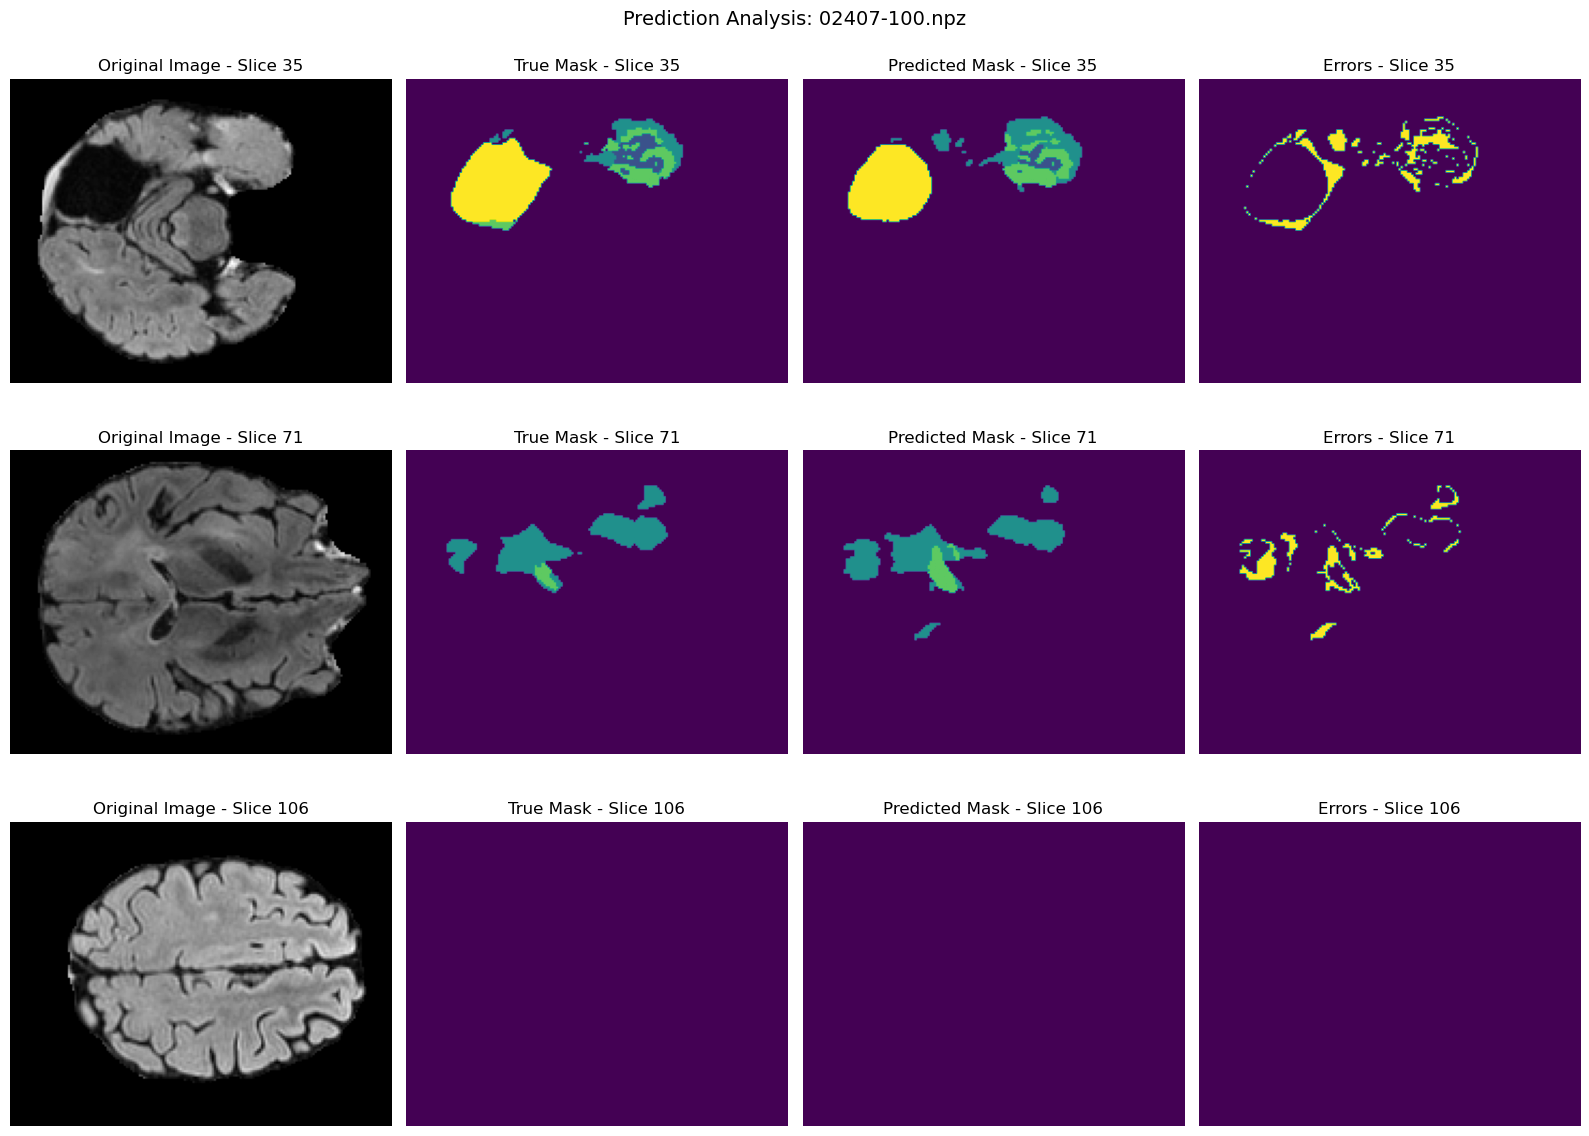

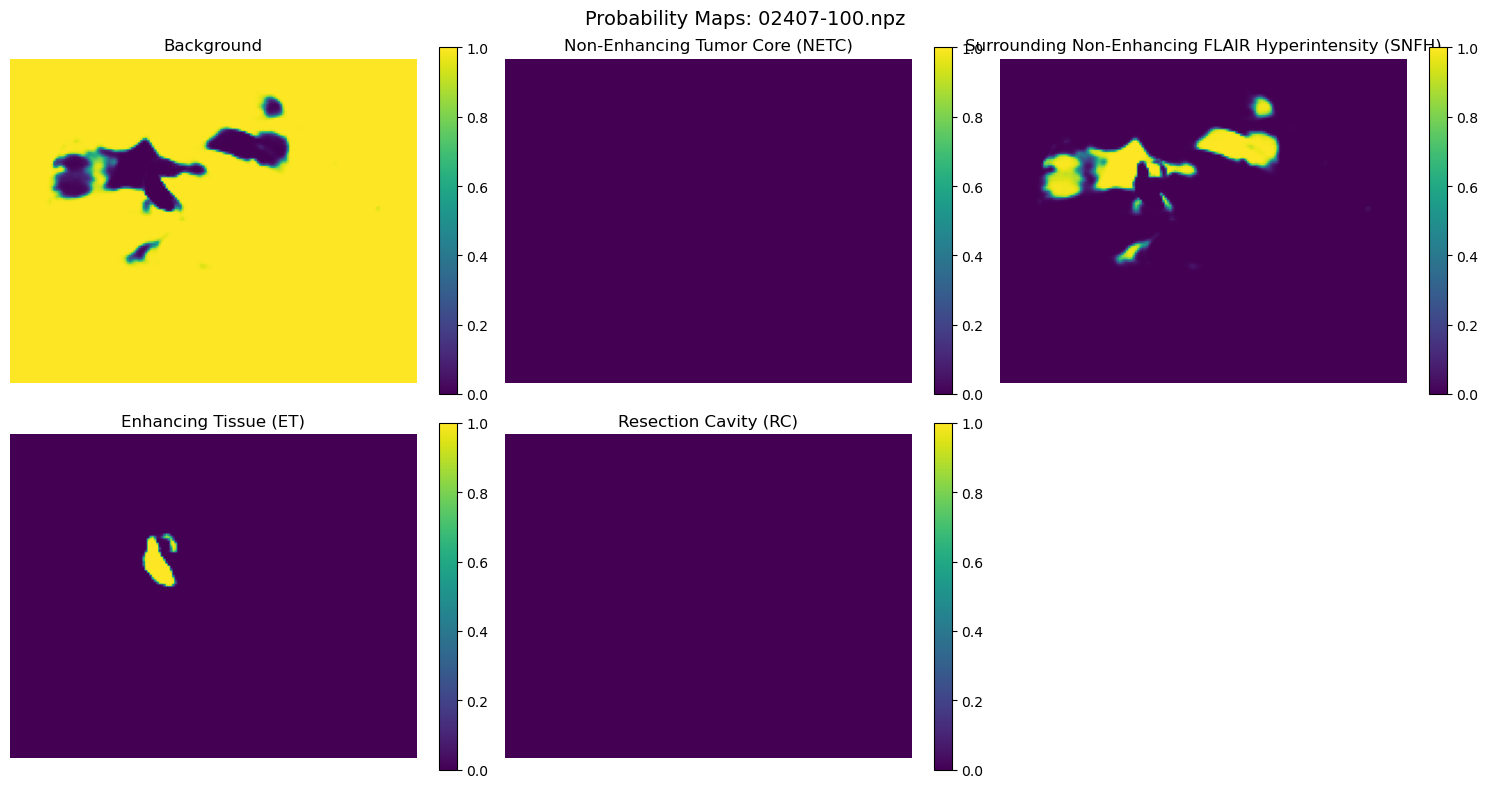


Processing: 02409-100.npz
Image shape: torch.Size([3, 142, 178, 142])
Mask shape: (142, 178, 142)
Overall Accuracy: 0.9915

Per-class metrics:
  class_0: IoU=0.9944, F1=0.9972, Support=3391010
  class_1: IoU=0.2538, F1=0.4048, Support=9669
  class_2: IoU=0.8637, F1=0.9269, Support=155764
  class_3: IoU=0.7870, F1=0.8808, Support=28459
  class_4: IoU=0.0000, F1=0.0000, Support=4290


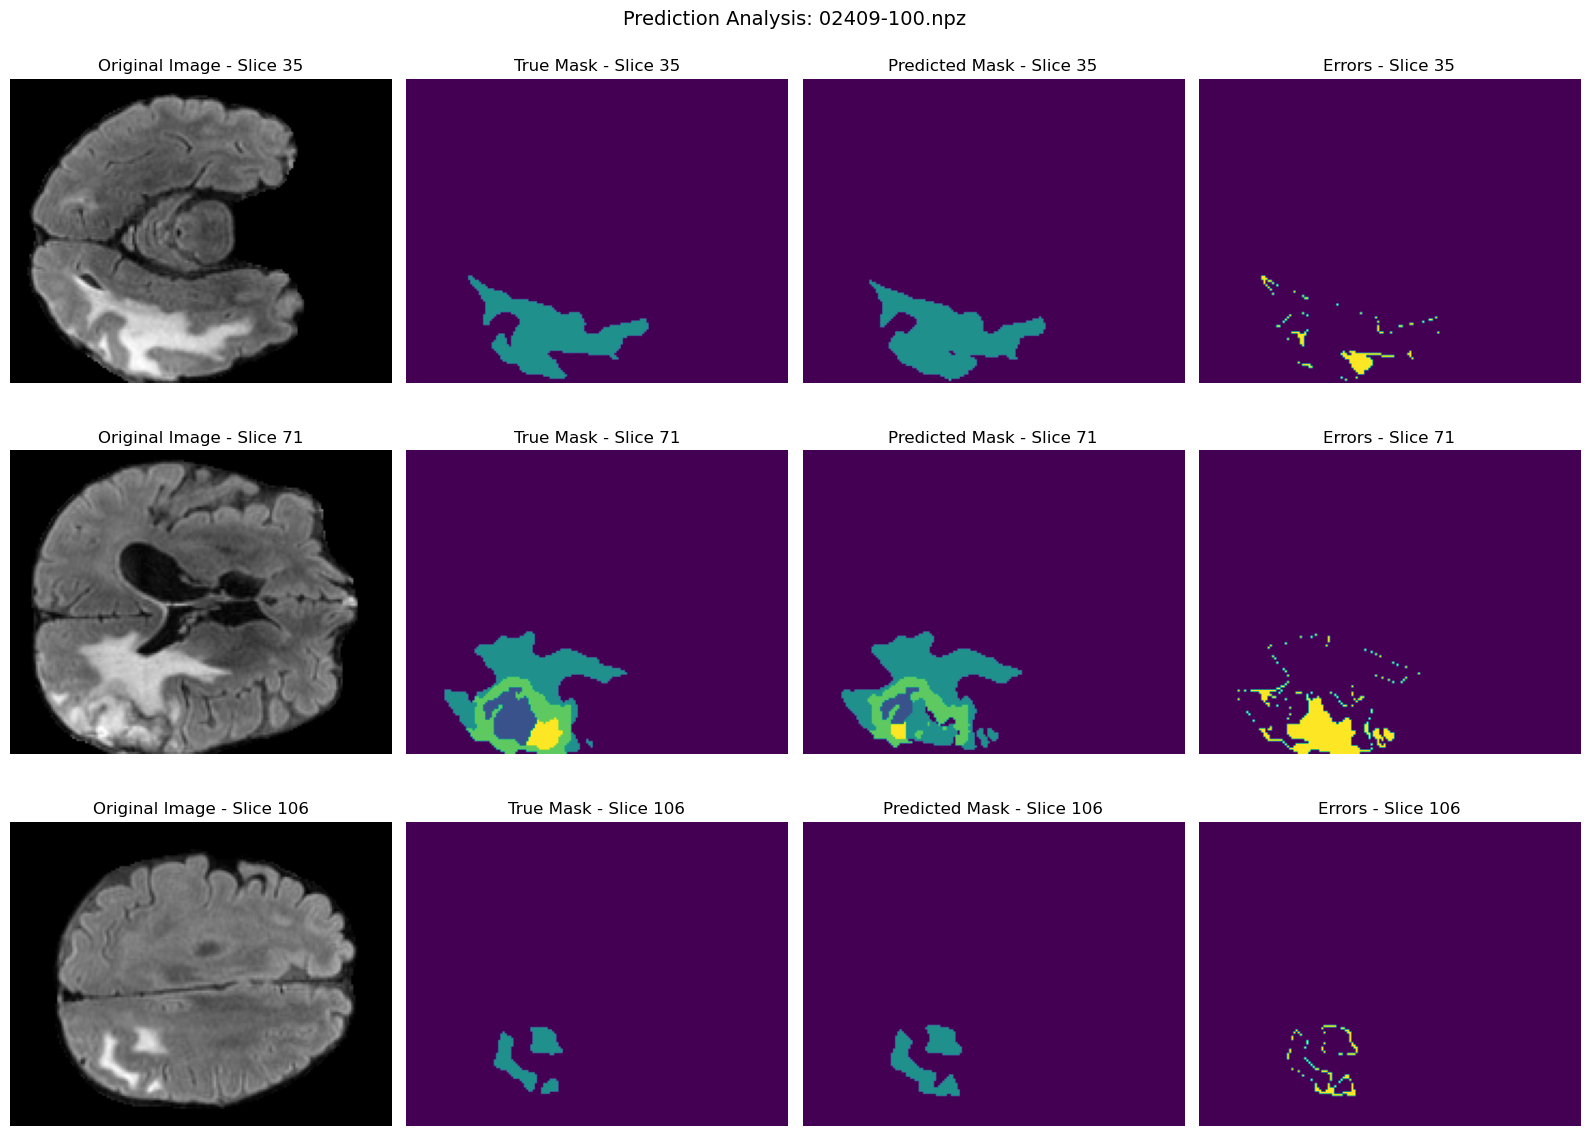

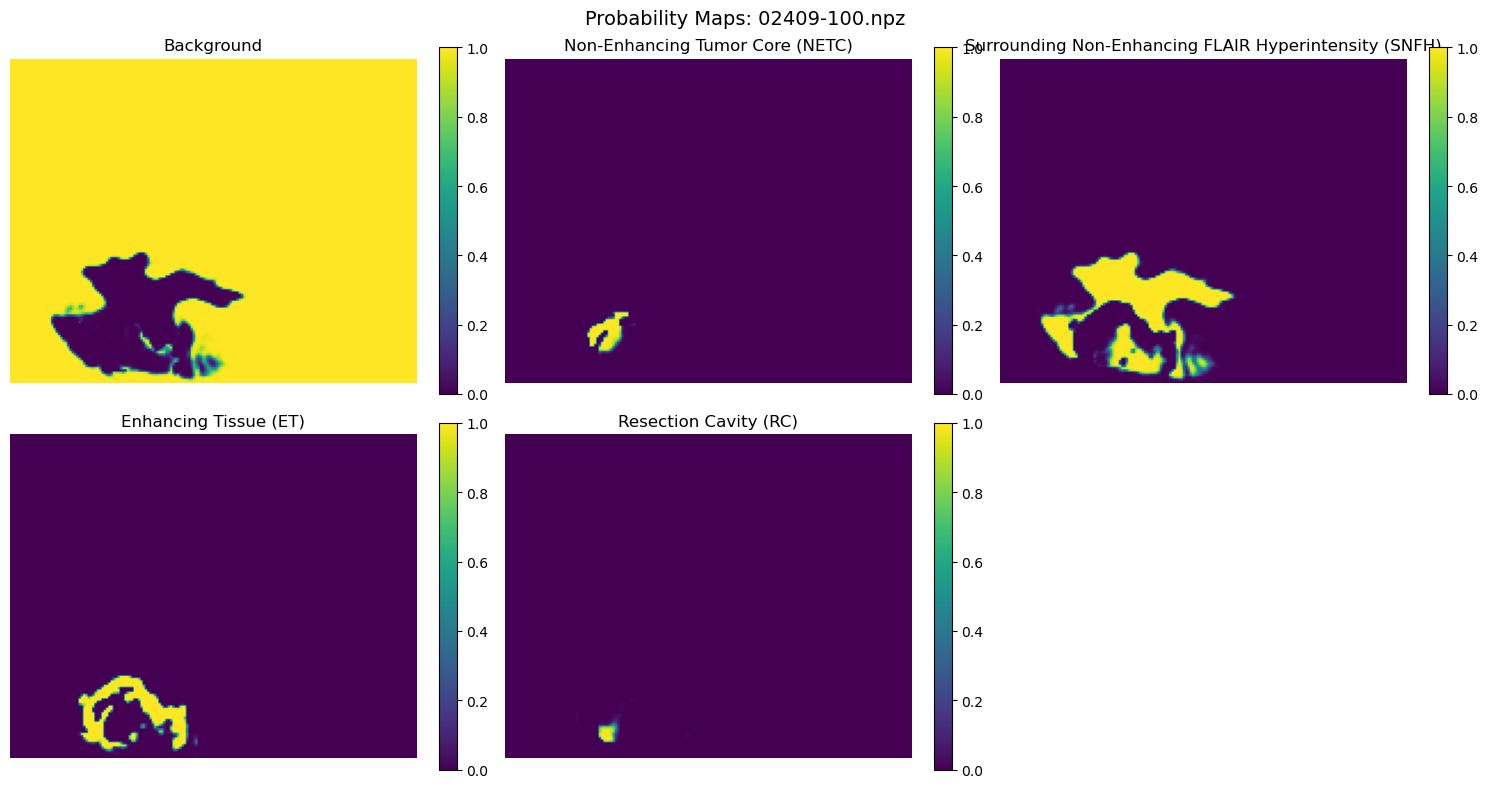


Processing: 02410-100.npz
Image shape: torch.Size([3, 142, 178, 142])
Mask shape: (142, 178, 142)
Overall Accuracy: 0.9975

Per-class metrics:
  class_0: IoU=0.9984, F1=0.9992, Support=3517122
  class_1: IoU=0.5443, F1=0.7050, Support=571
  class_2: IoU=0.8660, F1=0.9282, Support=45492
  class_3: IoU=0.8368, F1=0.9112, Support=15110
  class_4: IoU=0.7469, F1=0.8551, Support=10897


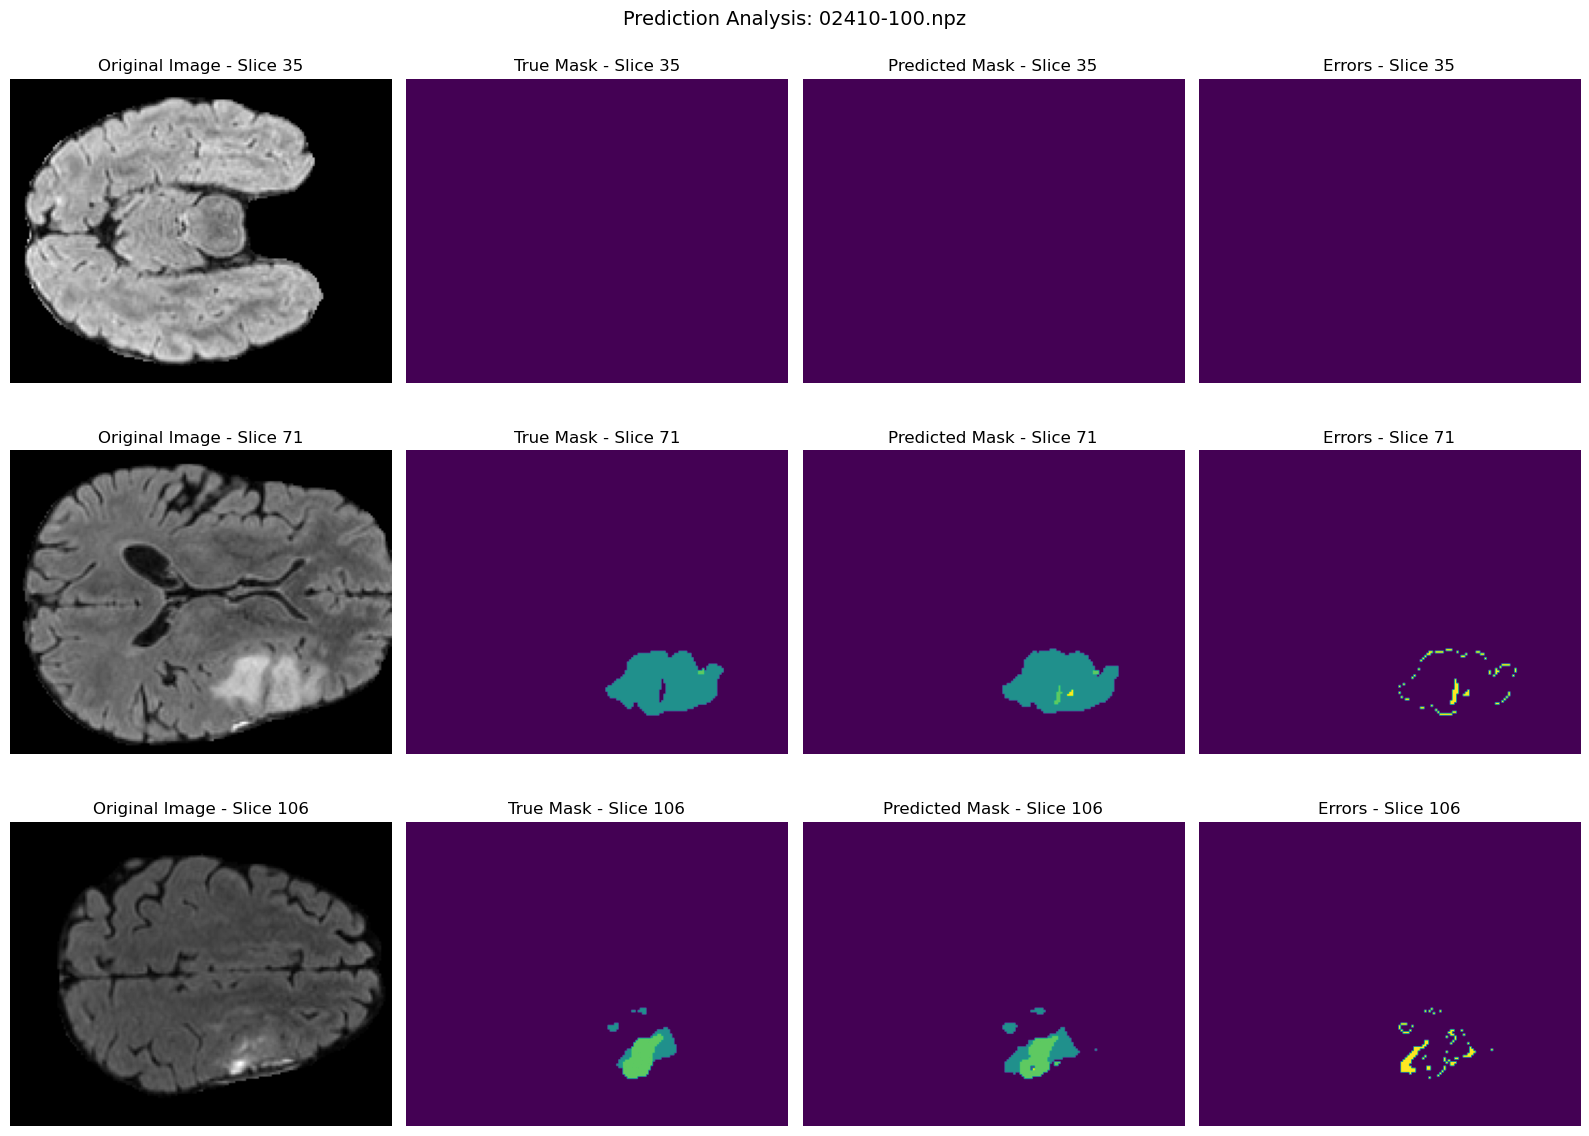

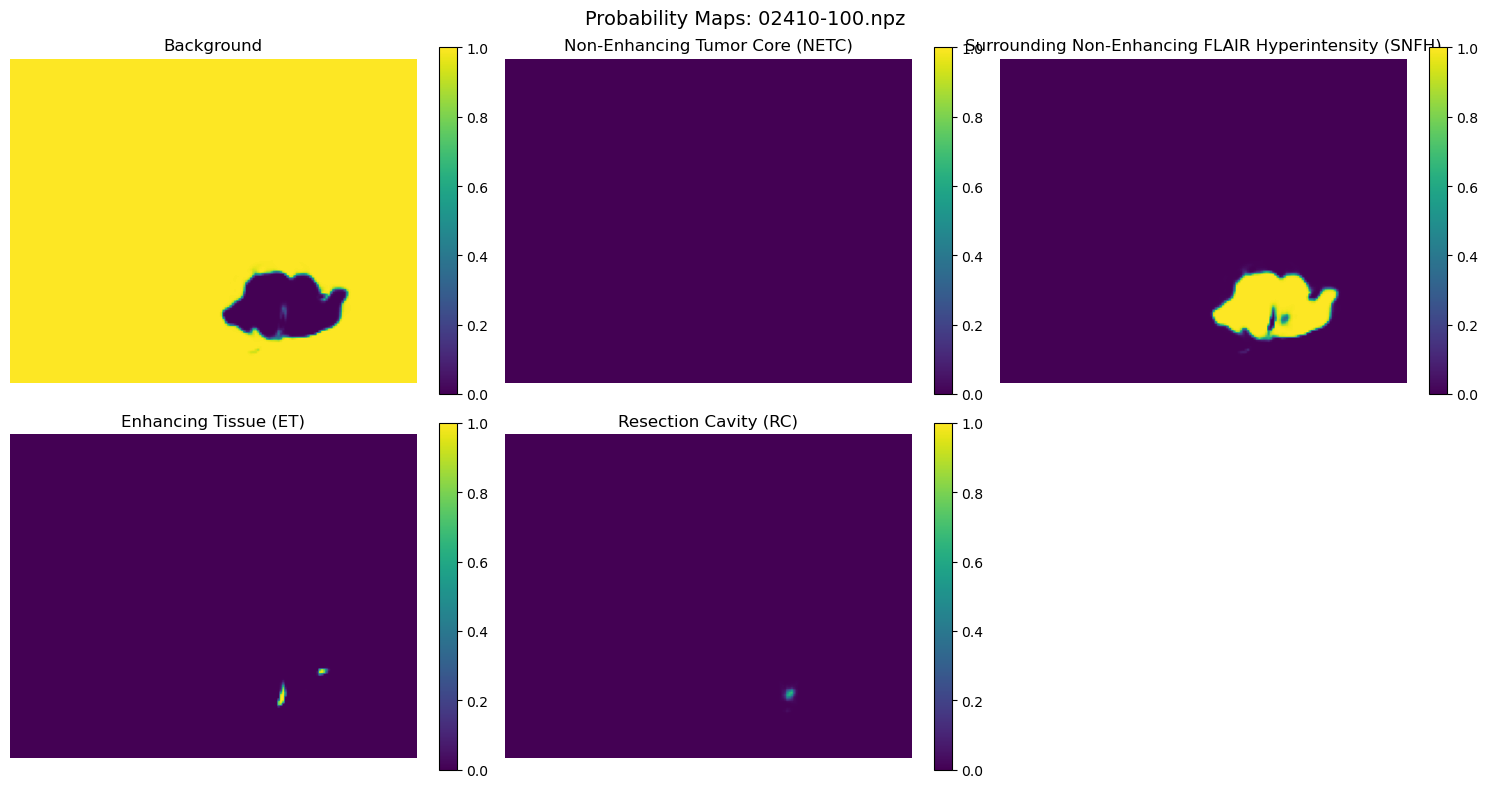


Processing: 02410-101.npz
Image shape: torch.Size([3, 142, 178, 142])
Mask shape: (142, 178, 142)
Overall Accuracy: 0.9969

Per-class metrics:
  class_0: IoU=0.9978, F1=0.9989, Support=3532475
  class_1: IoU=0.3613, F1=0.5309, Support=3355
  class_2: IoU=0.8204, F1=0.9013, Support=33290
  class_3: IoU=0.8121, F1=0.8963, Support=13835
  class_4: IoU=0.6458, F1=0.7848, Support=6237


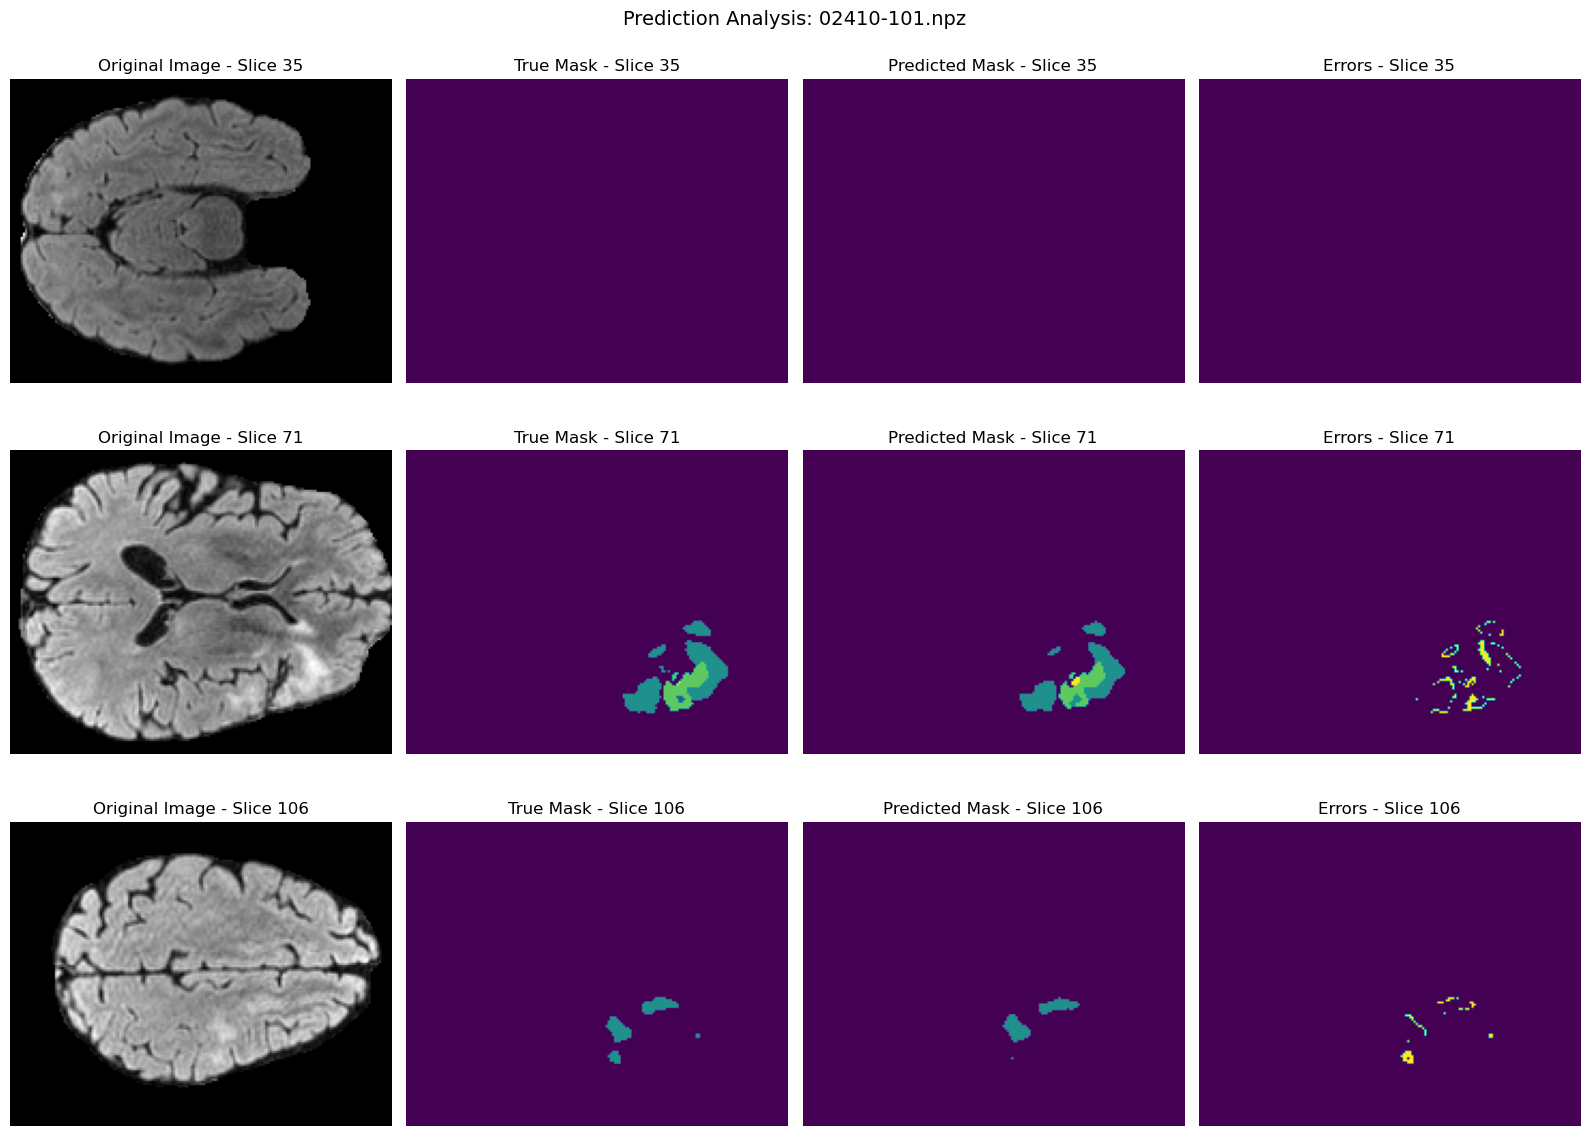

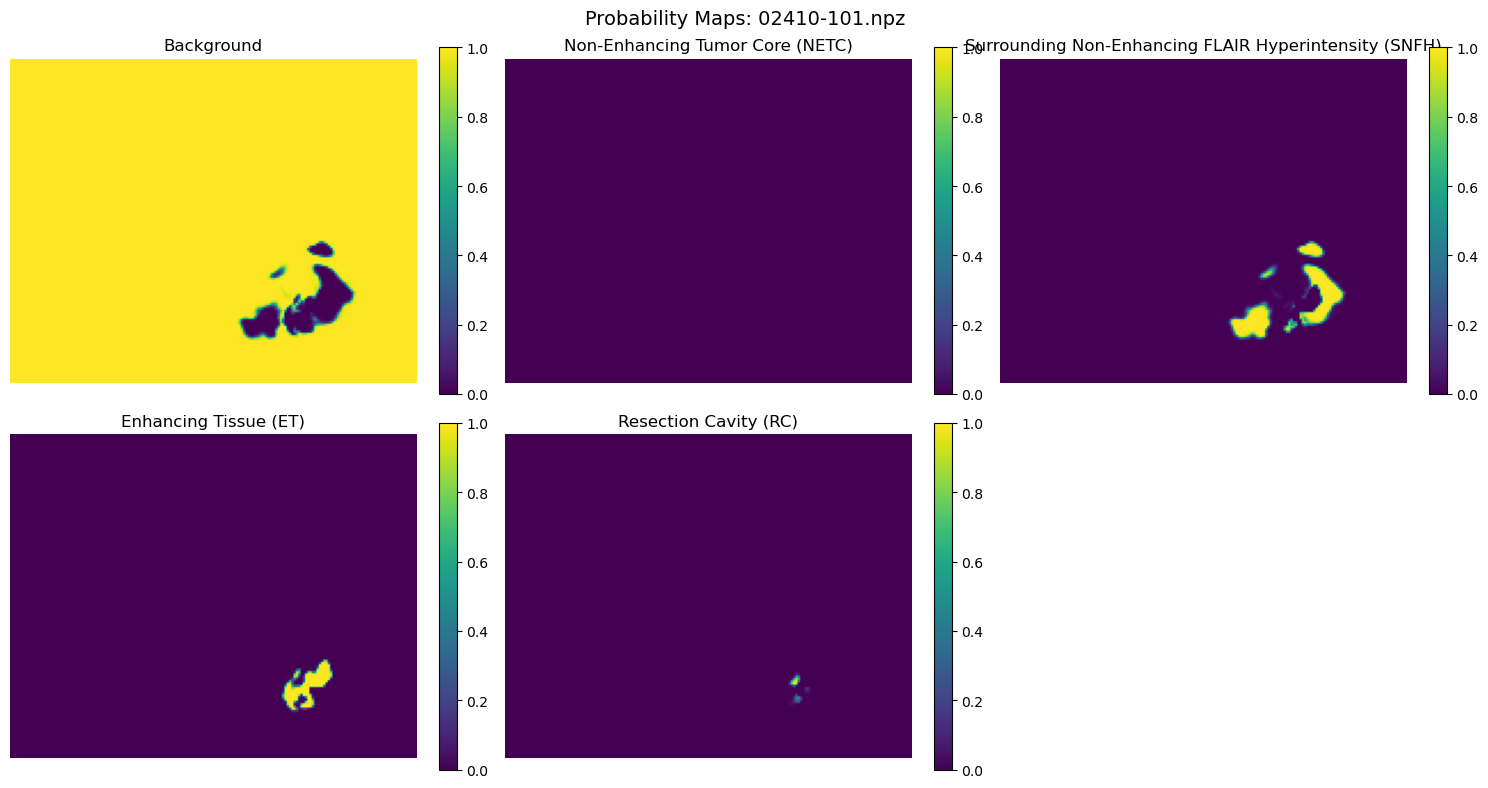


Processing: 02415-100.npz
Image shape: torch.Size([3, 142, 178, 142])
Mask shape: (142, 178, 142)
Overall Accuracy: 0.9949

Per-class metrics:
  class_0: IoU=0.9958, F1=0.9979, Support=3483415
  class_1: IoU=0.7018, F1=0.8248, Support=2463
  class_2: IoU=0.7989, F1=0.8882, Support=69422
  class_3: IoU=0.8542, F1=0.9214, Support=32422
  class_4: IoU=0.0459, F1=0.0878, Support=1470


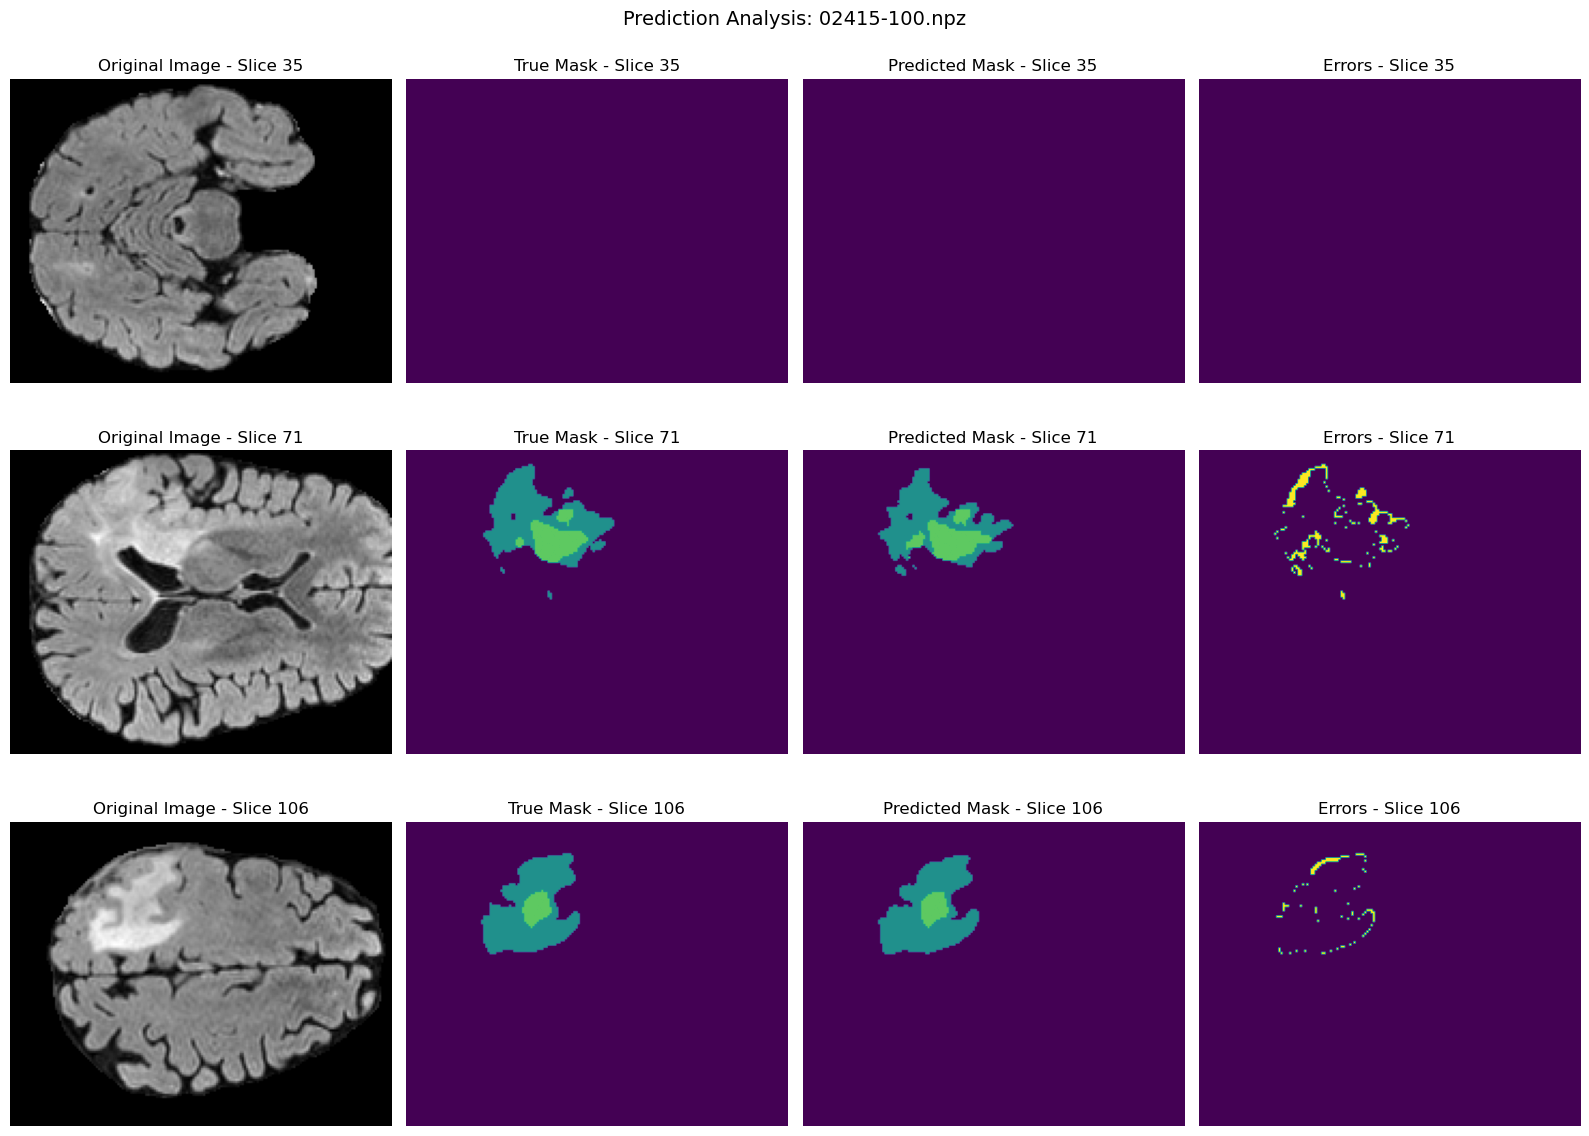

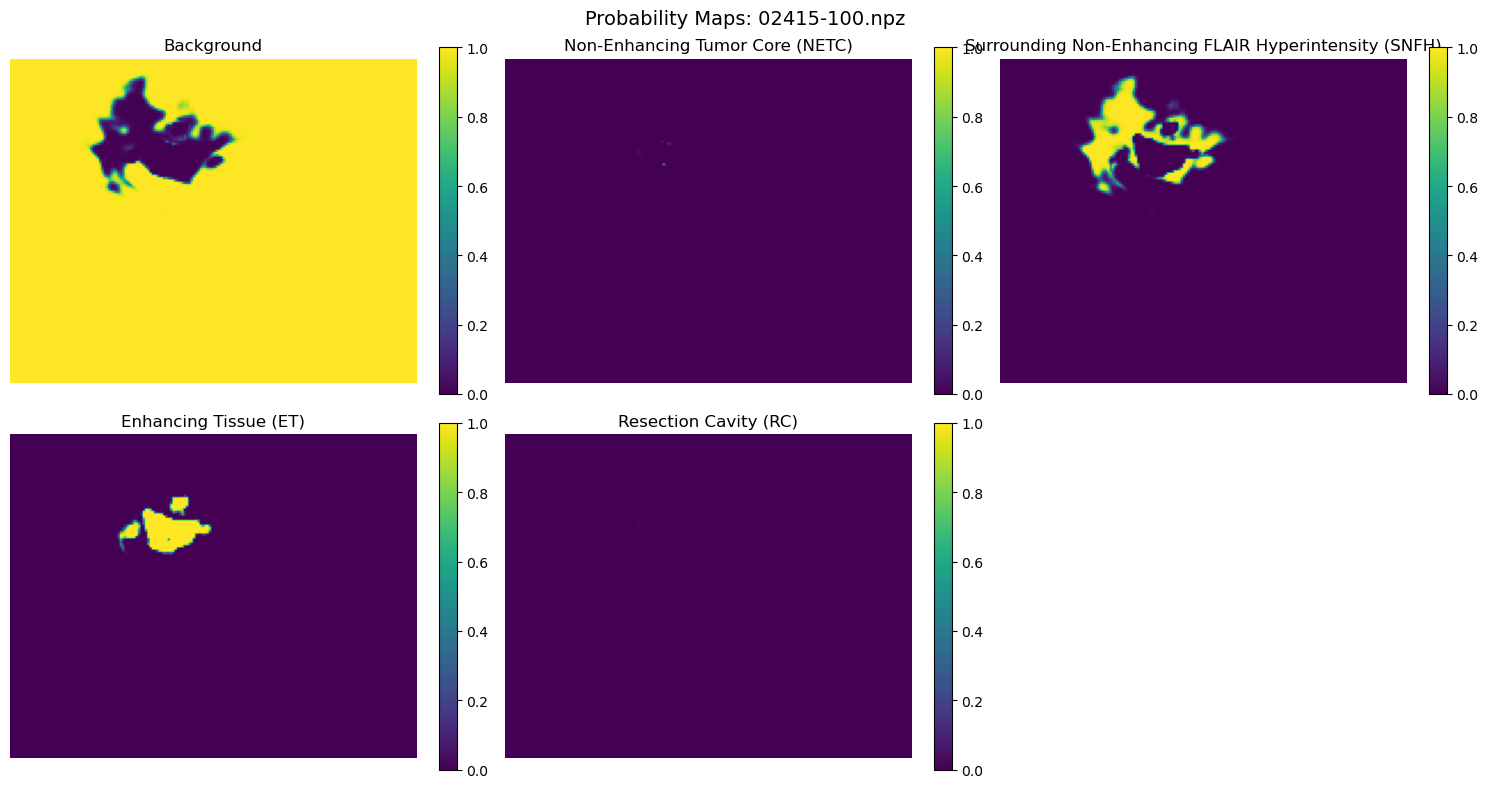


VALIDATION COMPLETE


In [10]:
# Run validation on a few samples
print("Running validation on test samples...")

all_metrics = []
sample_count = 0
max_samples = 5  # Analyze first 5 samples

for batch_idx, (images, masks, filenames) in enumerate(test_loader):
    if sample_count >= max_samples:
        break
        
    # Process each sample in batch (batch_size=1)
    for i in range(images.shape[0]):
        image = images[i]
        true_mask = masks[i].numpy()
        filename = filenames[i]
        
        print(f"\n{'='*50}")
        print(f"Processing: {filename}")
        print(f"Image shape: {image.shape}")
        print(f"Mask shape: {true_mask.shape}")
        
        # Predict
        pred_mask, probabilities = predict_single_volume(model, image, DEVICE)
        
        # Calculate metrics
        metrics = calculate_metrics(true_mask, pred_mask)
        metrics['filename'] = filename
        all_metrics.append(metrics)
        
        # Print metrics
        print(f"Overall Accuracy: {metrics['accuracy']:.4f}")
        print("\nPer-class metrics:")
        for class_name, class_metrics in metrics['class_metrics'].items():
            print(f"  {class_name}: IoU={class_metrics['iou']:.4f}, F1={class_metrics['f1']:.4f}, Support={class_metrics['support']}")
        
        # Visualize
        visualize_predictions(image.numpy(), true_mask, pred_mask, probabilities, filename)
        
        sample_count += 1
        
        # Clear memory
        torch.cuda.empty_cache()
        gc.collect()

print(f"\n{'='*60}")
print("VALIDATION COMPLETE")
print(f"{'='*60}")


=== VALIDATION SUMMARY ===
Average Accuracy: 0.9939

Average Per-Class Metrics:
  Class 0 - Background:
    IoU: 0.9955, F1: 0.9977, Total Support: 17379734
  Class 1 - Non-Enhancing Tumor Core (NETC):
    IoU: 0.4935, F1: 0.6441, Total Support: 22402
  Class 2 - Surrounding Non-Enhancing FLAIR Hyperintensity (SNFH):
    IoU: 0.8024, F1: 0.8884, Total Support: 360392
  Class 3 - Enhancing Tissue (ET):
    IoU: 0.8044, F1: 0.8910, Total Support: 131517
  Class 4 - Resection Cavity (RC):
    IoU: 0.4260, F1: 0.5090, Total Support: 51915


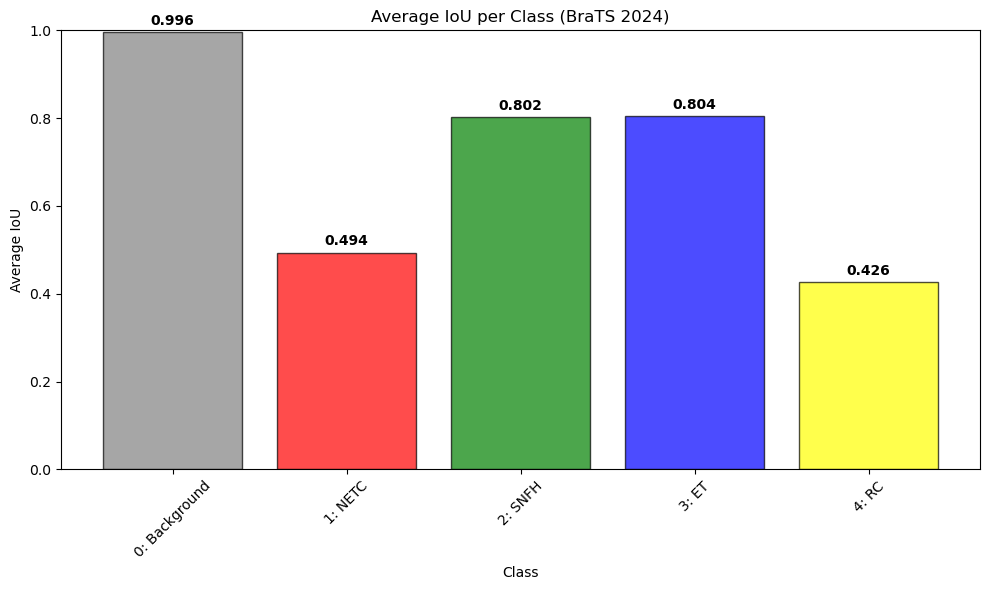

In [11]:
# Summary statistics
if all_metrics:
    # BraTS 2024 official class mapping
    class_names = {
        0: 'Background',
        1: 'Non-Enhancing Tumor Core (NETC)',           # Red - necrosis/cysts
        2: 'Surrounding Non-Enhancing FLAIR Hyperintensity (SNFH)', # Green - edema/infiltrating tumor
        3: 'Enhancing Tissue (ET)',                     # Blue - active tumor
        4: 'Resection Cavity (RC)'                      # Yellow - resection cavities
    }

    # Class colors for visualization
    class_colors = {
        0: 'gray',      # Background - gray
        1: 'red',       # NETC - red
        2: 'green',     # SNFH - green
        3: 'blue',      # ET - blue
        4: 'yellow'     # RC - yellow
    }

    print("\n=== VALIDATION SUMMARY ===")

    # Average accuracy
    avg_accuracy = np.mean([m['accuracy'] for m in all_metrics])
    print(f"Average Accuracy: {avg_accuracy:.4f}")

    # Average per-class metrics with proper names
    print("\nAverage Per-Class Metrics:")
    for class_id in range(5):
        class_key = f'class_{class_id}'
        avg_iou = np.mean([m['class_metrics'][class_key]['iou'] for m in all_metrics])
        avg_f1 = np.mean([m['class_metrics'][class_key]['f1'] for m in all_metrics])
        total_support = sum([m['class_metrics'][class_key]['support'] for m in all_metrics])
        class_name = class_names[class_id]
        print(f"  Class {class_id} - {class_name}:")
        print(f"    IoU: {avg_iou:.4f}, F1: {avg_f1:.4f}, Total Support: {total_support}")

    # Create IoU per class plot with proper colors
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))

    # Average IoU per class with proper labels and colors
    class_ious = []
    class_labels = []
    bar_colors = []

    for class_id in range(5):
        class_key = f'class_{class_id}'
        avg_iou = np.mean([m['class_metrics'][class_key]['iou'] for m in all_metrics])
        class_ious.append(avg_iou)
        # Shorter labels for plot readability
        short_names = {0: 'Background', 1: 'NETC', 2: 'SNFH', 3: 'ET', 4: 'RC'}
        class_labels.append(f'{class_id}: {short_names[class_id]}')
        bar_colors.append(class_colors[class_id])

    bars = ax.bar(range(5), class_ious, color=bar_colors, alpha=0.7, edgecolor='black', linewidth=1)
    ax.set_xlabel('Class')
    ax.set_ylabel('Average IoU')
    ax.set_title('Average IoU per Class (BraTS 2024)')
    ax.set_xticks(range(5))
    ax.set_xticklabels(class_labels, rotation=45)
    ax.set_ylim(0, 1)  # IoU ranges from 0 to 1

    # Add value labels on top of bars
    for i, (bar, iou_val) in enumerate(zip(bars, class_ious)):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{iou_val:.3f}', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print("No metrics calculated!")

In [12]:
# Optional: Run full test set evaluation (this will take longer)
run_full_evaluation = True  # Set to True if you want to evaluate entire test set

if run_full_evaluation:
    print("Running full test set evaluation...")
    
    full_metrics = []
    
    with tqdm(total=len(test_loader), desc="Evaluating") as pbar:
        for images, masks, filenames in test_loader:
            for i in range(images.shape[0]):
                image = images[i]
                true_mask = masks[i].numpy()
                filename = filenames[i]
                
                # Predict
                pred_mask, _ = predict_single_volume(model, image, DEVICE)
                
                # Calculate metrics
                metrics = calculate_metrics(true_mask, pred_mask)
                metrics['filename'] = filename
                full_metrics.append(metrics)
                
            pbar.update(1)
            
            # Clear memory periodically
            if pbar.n % 10 == 0:
                torch.cuda.empty_cache()
                gc.collect()
    
    # Print full evaluation results
    print(f"\n{'='*60}")
    print("FULL TEST SET EVALUATION")
    print(f"{'='*60}")
    
    avg_accuracy = np.mean([m['accuracy'] for m in full_metrics])
    print(f"Average Accuracy: {avg_accuracy:.4f} ± {np.std([m['accuracy'] for m in full_metrics]):.4f}")
    
    print("\nPer-Class Results:")
    for class_id in range(5):
        class_key = f'class_{class_id}'
        ious = [m['class_metrics'][class_key]['iou'] for m in full_metrics]
        f1s = [m['class_metrics'][class_key]['f1'] for m in full_metrics]
        print(f"  Class {class_id}: IoU={np.mean(ious):.4f}±{np.std(ious):.4f}, F1={np.mean(f1s):.4f}±{np.std(f1s):.4f}")
else:
    print("\nTo run full evaluation, set run_full_evaluation = True")

Running full test set evaluation...


Evaluating: 100%|██████████| 110/110 [05:27<00:00,  2.97s/it]


FULL TEST SET EVALUATION
Average Accuracy: 0.9939 ± 0.0041

Per-Class Results:
  Class 0: IoU=0.9955±0.0030, F1=0.9977±0.0015
  Class 1: IoU=0.3497±0.2900, F1=0.4491±0.3261
  Class 2: IoU=0.7426±0.1552, F1=0.8411±0.1287
  Class 3: IoU=0.7076±0.1834, F1=0.8117±0.1627
  Class 4: IoU=0.2959±0.2933, F1=0.3822±0.3326


Running FULL dataset evaluation for comprehensive analysis...
Evaluating all 110 samples...


Full Dataset Evaluation: 100%|██████████| 110/110 [05:21<00:00,  2.93s/it]



FULL DATASET EVALUATION RESULTS
Overall Accuracy: 0.9939 ± 0.0041

Per-Class Results (n=110 samples):
--------------------------------------------------------------------------------
Class 0 - Background:
  IoU:       0.9955 ± 0.0030
  F1-Score:  0.9977 ± 0.0015
  Precision: 0.9977
  Recall:    0.9978

Class 1 - Non-Enhancing Tumor Core (NETC):
  IoU:       0.3497 ± 0.2900
  F1-Score:  0.4491 ± 0.3261
  Precision: 0.5804
  Recall:    0.5135

Class 2 - Surrounding Non-Enhancing FLAIR Hyperintensity (SNFH):
  IoU:       0.7426 ± 0.1552
  F1-Score:  0.8411 ± 0.1287
  Precision: 0.8593
  Recall:    0.8424

Class 3 - Enhancing Tissue (ET):
  IoU:       0.7076 ± 0.1834
  F1-Score:  0.8117 ± 0.1627
  Precision: 0.8217
  Recall:    0.8418

Class 4 - Resection Cavity (RC):
  IoU:       0.2959 ± 0.2933
  F1-Score:  0.3822 ± 0.3326
  Precision: 0.5045
  Recall:    0.4630



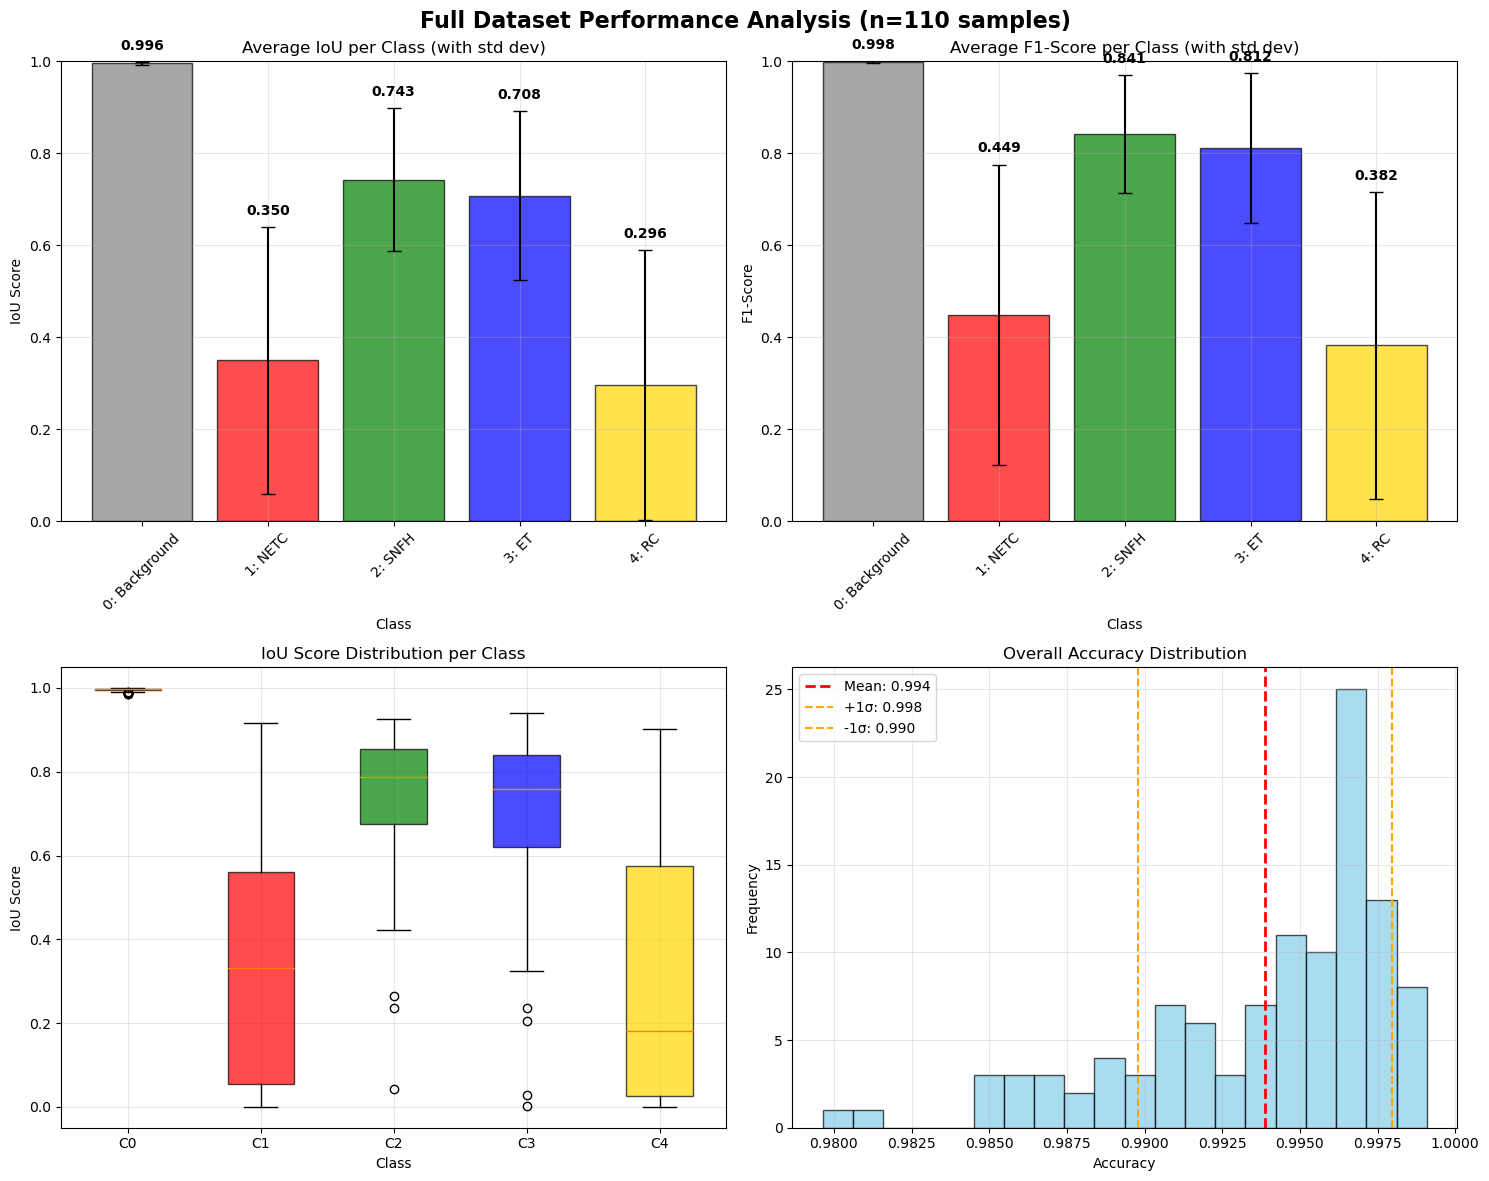


PERFORMANCE SUMMARY TABLE
Class Name                                IoU          F1-Score     Precision    Recall      
--------------------------------------------------------------------------------
0     Background                          0.9955±0.003  0.9977±0.002  0.9977      0.9978
1     Non-Enhancing Tumor Core (NETC      0.3497±0.290  0.4491±0.326  0.5804      0.5135
2     Surrounding Non-Enhancing FLAI      0.7426±0.155  0.8411±0.129  0.8593      0.8424
3     Enhancing Tissue (ET)               0.7076±0.183  0.8117±0.163  0.8217      0.8418
4     Resection Cavity (RC)               0.2959±0.293  0.3822±0.333  0.5045      0.4630
--------------------------------------------------------------------------------
Overall Accuracy:                          0.9939 ± 0.0041

Evaluation complete! Check 'full_dataset_evaluation.png' for saved visualization.


In [13]:
# Full Dataset Evaluation with Comprehensive Visualization
print("Running FULL dataset evaluation for comprehensive analysis...")

# Set to True to run full evaluation
run_full_evaluation = True

if run_full_evaluation:
    full_metrics = []

    print(f"Evaluating all {len(test_loader)} samples...")

    with tqdm(total=len(test_loader), desc="Full Dataset Evaluation") as pbar:
        for images, masks, filenames in test_loader:
            for i in range(images.shape[0]):
                image = images[i]
                true_mask = masks[i].numpy()
                filename = filenames[i]

                # Predict
                pred_mask, _ = predict_single_volume(model, image, DEVICE)

                # Calculate metrics
                metrics = calculate_metrics(true_mask, pred_mask)
                metrics['filename'] = filename
                full_metrics.append(metrics)

            pbar.update(1)

            # Clear memory periodically
            if pbar.n % 20 == 0:
                torch.cuda.empty_cache()
                gc.collect()

    # Calculate comprehensive statistics
    print(f"\n{'='*70}")
    print("FULL DATASET EVALUATION RESULTS")
    print(f"{'='*70}")

    # Overall accuracy
    accuracies = [m['accuracy'] for m in full_metrics]
    avg_accuracy = np.mean(accuracies)
    std_accuracy = np.std(accuracies)
    print(f"Overall Accuracy: {avg_accuracy:.4f} ± {std_accuracy:.4f}")

    # BraTS 2024 class mapping and colors
    class_names = {
        0: 'Background',
        1: 'Non-Enhancing Tumor Core (NETC)',
        2: 'Surrounding Non-Enhancing FLAIR Hyperintensity (SNFH)',
        3: 'Enhancing Tissue (ET)',
        4: 'Resection Cavity (RC)'
    }

    class_colors = {
        0: 'gray',
        1: 'red',
        2: 'green',
        3: 'blue',
        4: 'gold'
    }

    # Collect per-class metrics
    class_stats = {}
    for class_id in range(5):
        class_key = f'class_{class_id}'
        ious = [m['class_metrics'][class_key]['iou'] for m in full_metrics]
        f1s = [m['class_metrics'][class_key]['f1'] for m in full_metrics]
        precisions = [m['class_metrics'][class_key]['precision'] for m in full_metrics]
        recalls = [m['class_metrics'][class_key]['recall'] for m in full_metrics]

        class_stats[class_id] = {
            'iou_mean': np.mean(ious),
            'iou_std': np.std(ious),
            'f1_mean': np.mean(f1s),
            'f1_std': np.std(f1s),
            'precision_mean': np.mean(precisions),
            'recall_mean': np.mean(recalls),
            'iou_values': ious,
            'f1_values': f1s
        }

    # Print detailed results
    print(f"\nPer-Class Results (n={len(full_metrics)} samples):")
    print("-" * 80)
    for class_id in range(5):
        stats = class_stats[class_id]
        class_name = class_names[class_id]
        print(f"Class {class_id} - {class_name}:")
        print(f"  IoU:       {stats['iou_mean']:.4f} ± {stats['iou_std']:.4f}")
        print(f"  F1-Score:  {stats['f1_mean']:.4f} ± {stats['f1_std']:.4f}")
        print(f"  Precision: {stats['precision_mean']:.4f}")
        print(f"  Recall:    {stats['recall_mean']:.4f}")
        print()

    # Create comprehensive visualization
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle(f'Full Dataset Performance Analysis (n={len(full_metrics)} samples)', fontsize=16, fontweight='bold')

    # 1. IoU per class with error bars
    class_ids = list(range(5))
    iou_means = [class_stats[i]['iou_mean'] for i in class_ids]
    iou_stds = [class_stats[i]['iou_std'] for i in class_ids]
    colors = [class_colors[i] for i in class_ids]
    short_labels = ['Background', 'NETC', 'SNFH', 'ET', 'RC']

    bars1 = ax1.bar(class_ids, iou_means, yerr=iou_stds, capsize=5,
                    color=colors, alpha=0.7, edgecolor='black', linewidth=1)
    ax1.set_xlabel('Class')
    ax1.set_ylabel('IoU Score')
    ax1.set_title('Average IoU per Class (with std dev)')
    ax1.set_xticks(class_ids)
    ax1.set_xticklabels([f'{i}: {short_labels[i]}' for i in class_ids], rotation=45)
    ax1.set_ylim(0, 1)
    ax1.grid(True, alpha=0.3)

    # Add value labels
    for i, (bar, mean_val, std_val) in enumerate(zip(bars1, iou_means, iou_stds)):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std_val + 0.02,
                f'{mean_val:.3f}', ha='center', va='bottom', fontweight='bold')

    # 2. F1-Score comparison
    f1_means = [class_stats[i]['f1_mean'] for i in class_ids]
    f1_stds = [class_stats[i]['f1_std'] for i in class_ids]

    bars2 = ax2.bar(class_ids, f1_means, yerr=f1_stds, capsize=5,
                    color=colors, alpha=0.7, edgecolor='black', linewidth=1)
    ax2.set_xlabel('Class')
    ax2.set_ylabel('F1-Score')
    ax2.set_title('Average F1-Score per Class (with std dev)')
    ax2.set_xticks(class_ids)
    ax2.set_xticklabels([f'{i}: {short_labels[i]}' for i in class_ids], rotation=45)
    ax2.set_ylim(0, 1)
    ax2.grid(True, alpha=0.3)

    # Add value labels
    for i, (bar, mean_val, std_val) in enumerate(zip(bars2, f1_means, f1_stds)):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std_val + 0.02,
                f'{mean_val:.3f}', ha='center', va='bottom', fontweight='bold')

    # 3. IoU distribution boxplot
    iou_data = [class_stats[i]['iou_values'] for i in class_ids]
    box1 = ax3.boxplot(iou_data, labels=[f'C{i}' for i in class_ids], patch_artist=True)
    for patch, color in zip(box1['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax3.set_xlabel('Class')
    ax3.set_ylabel('IoU Score')
    ax3.set_title('IoU Score Distribution per Class')
    ax3.grid(True, alpha=0.3)

    # 4. Overall accuracy distribution
    ax4.hist(accuracies, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    ax4.axvline(avg_accuracy, color='red', linestyle='--', linewidth=2,
                label=f'Mean: {avg_accuracy:.3f}')
    ax4.axvline(avg_accuracy + std_accuracy, color='orange', linestyle='--',
                label=f'+1σ: {avg_accuracy + std_accuracy:.3f}')
    ax4.axvline(avg_accuracy - std_accuracy, color='orange', linestyle='--',
                label=f'-1σ: {avg_accuracy - std_accuracy:.3f}')
    ax4.set_xlabel('Accuracy')
    ax4.set_ylabel('Frequency')
    ax4.set_title('Overall Accuracy Distribution')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('full_dataset_evaluation.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Summary table
    print("\n" + "="*80)
    print("PERFORMANCE SUMMARY TABLE")
    print("="*80)
    print(f"{'Class':<5} {'Name':<35} {'IoU':<12} {'F1-Score':<12} {'Precision':<12} {'Recall':<12}")
    print("-" * 80)
    for class_id in range(5):
        stats = class_stats[class_id]
        name = class_names[class_id][:30]  # Truncate long names
        print(f"{class_id:<5} {name:<35} "
            f"{stats['iou_mean']:.4f}±{stats['iou_std']:.3f}  "
            f"{stats['f1_mean']:.4f}±{stats['f1_std']:.3f}  "
            f"{stats['precision_mean']:.4f}      "
            f"{stats['recall_mean']:.4f}")
    print("-" * 80)
    print(f"{'Overall Accuracy:':<42} {avg_accuracy:.4f} ± {std_accuracy:.4f}")
    print("="*80)

else:
    print("Set run_full_evaluation = True to run comprehensive evaluation")

print("\nEvaluation complete! Check 'full_dataset_evaluation.png' for saved visualization.")